# Playing With Printing

This notebook has examples of how to use most of the non-pybullet classes along with visualization. 

PRRT with 6 SOC Agents

In [15]:
import sys
sys.path.append('../src')

from Environments import *
from Agents import SecondOrderCar
# must use the moving obs version of the is new node valid func for PRRT!
from prrt import PRRT
from printer import MultiRRTPrinter
import math

In [16]:
# Create some obstacles. For PRRT, each obstacle must 
# have a time element 
obstacles = [CircularObstacle2DTimed(10, 10, 2),
            CircularObstacle2DTimed(18, 16, 3),
            CircularObstacle2DTimed(20, 5, 3)
            ] 
                    
# create an environment with the given obstacles 
env = SquareEnvironment(40, 40, obstacles)
edge_bundle = None

# create some start/goals
goal = (33.0, 10.0, math.pi, 0.0)
start = (14.0, 2.0, math.pi/2, 0.0, 0.0)

start2 = (5.0, 2.0, 0.0, 0.0, 0.0)
goal2 = (25.0, 25.0, math.pi/2, 0.0)

start3 = (30.0, 5.0, math.pi, 0.0, 0.0)
goal3 = (5.0, 30.0, math.pi/2, 0.0)

start4 = (30.0, 20.0, math.pi, 0.0, 0.0)
goal4 = (2.0, 10.0, math.pi/2, 0.0)

start5 = (27.0, 15.0, math.pi, 0.0, 0.0)
goal5 = (10.0, 3.0, math.pi/2, 0.0)

start6 = (20.0, 32.0, math.pi, 0.0, 0.0)
goal6 = (27.0, 4.0, math.pi/2, 0.0)

# curate lists for call to PRRT 
agents = [SecondOrderCar(agent_id=i) for i in range(6)]
starts = [start, start2, start3, start4, start5, start6]
goals = [goal, goal2, goal3, goal4, goal5, goal6]
goal_radii = [2.0, 2.0, 2.0, 2.0, 2.0, 2.0]
isvalid_fucs = [SecondOrderCar.is_new_node_valid for _ in range(len(agents))]
cost_funcs = [SecondOrderCar.get_cost for _ in range(len(agents))]
random_pt_funcs = [SecondOrderCar.get_random_point for _ in range(len(agents))]
reached_goal_funcs = [SecondOrderCar.agent_reached_goal for _ in range(len(agents))]

(paths, states, controls, timesteps, rrts, end_time) = PRRT.plan_multi(agents=agents, 
                                        starts=starts,
                                        goals=goals,
                                        goal_radii=goal_radii,
                                        env=env,
                                        max_iter = 300000, planning_time=math.inf,         
                                        isvalid_function=isvalid_fucs, 
                                        cost_function=cost_funcs,
                                        random_point_function=random_pt_funcs, 
                                        reached_goal_function = reached_goal_funcs,
                                        udf_seed = 158,
                                        print_logs=True
                                        )

New Agent at 1.1920928955078125e-06 seconds.
Total Planning Time for agent 0 after 185076 iterations:  23.571161031723022
New Agent at 23.57505178451538 seconds.
Total Planning Time for agent 1 after 8348 iterations:  0.34159111976623535
New Agent at 23.919819116592407 seconds.
Total Planning Time for agent 2 after 100088 iterations:  8.203372955322266
New Agent at 32.1269006729126 seconds.
Total Planning Time for agent 3 after 3118 iterations:  0.11375927925109863
New Agent at 32.24314785003662 seconds.
Total Planning Time for agent 4 after 5779 iterations:  0.22189855575561523
New Agent at 32.46673250198364 seconds.
Total Planning Time for agent 5 after 3423 iterations:  0.12898707389831543


Nodes gather skipped
Nodes gathered


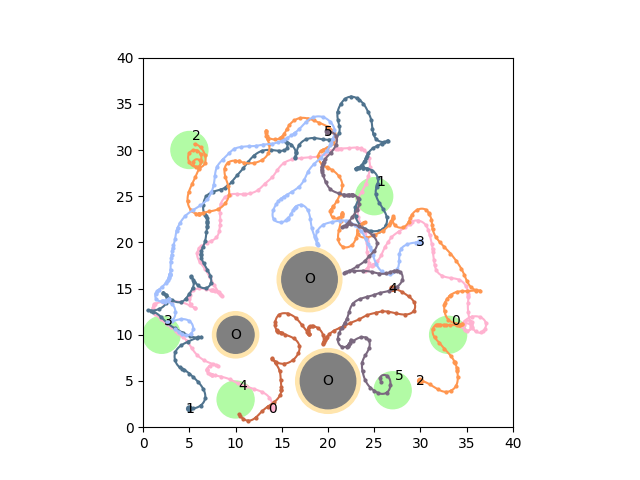

In [17]:
# define a list of colors for trees and paths to use in drawing function
tcol =['y', 'c', 'b', 'g', 'b', 'b']
pcol = ['xkcd:powder pink', 'xkcd:metallic blue', 'xkcd:pastel orange', 'xkcd:pastel blue', 'xkcd:terracotta', 'xkcd:purplish grey']

mprint = MultiRRTPrinter(env, rrts, paths, tcol, pcol)
# setting print_tree to true will show the tree as well
mprint.print_rrt('../media/six_soc_prrt.png', print_tree=False)

Nodes gather skipped
Nodes gathered
Start Gathering: 
Gathering for agent number: 0
Gathering for agent number: 1
Gathering for agent number: 2
Done gathering, now animating
Done animating, now saving


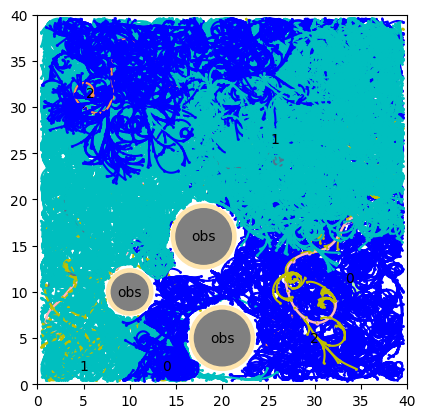

In [ ]:
# print an animation for three of the agents, along with their trees at each 
# timestep
mprint = MultiRRTPrinter(env, rrts[:3], paths[:3], tcol[:3], pcol[:3])
# set print_tree to false to not show trees. 
# The speed param is the time between each 
# step in the gif (lower number->faster animation speed)
mprint.print_rrt_animation('../media/three_soc_prrt_trees.png', animation_speed=50, print_tree=True)

Nodes gather skipped
Nodes gathered
Start Gathering: 
Gathering for agent: 0
Gathering for agent: 1
Gathering for agent: 2
Gathering for agent: 3
Gathering for agent: 4
Gathering for agent: 5
Done gathering, now animating
Done animating, now saving


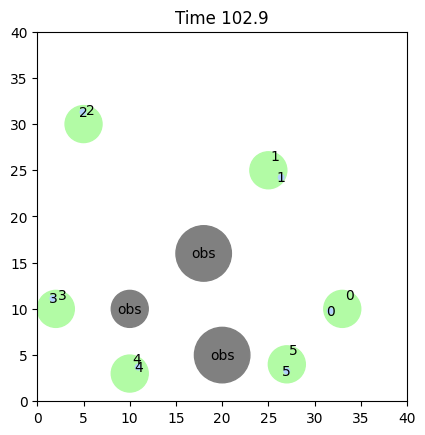

In [ ]:
# Print a simulation of the agents as they move through the env
mprint = MultiRRTPrinter(env, rrts, paths, [],[])
# get high-res paths for each agent 
highres_paths = dict(enumerate([planner.get_high_resolution_path() for planner in rrts]))
# The speed param is the time between each 
# step in the gif (lower number->faster animation speed)
mprint.print_highres_simulation(highres_paths, '../media/six_soc_prrt_sim.gif', animation_speed=100)

PRRT with 6 Unicycle agents using Edge Bundles

In [17]:
import sys
sys.path.append('../src')

from Environments import *
from Agents import UniCycle
# Utility funcs for 
# must use the moving_obs version 
from prrt_eb import EdgeBundlePRRT
from printer import MultiRRTPrinter
import math

In [18]:
# Create some obstacles. For PRRT, each obstacle must 
# have a time element 
obstacles = [CircularObstacle2DTimed(10, 10, 2),
            CircularObstacle2DTimed(18, 16, 3),
            CircularObstacle2DTimed(20, 5, 3)
            ] 

# create an environment with the given obstacles                
env = SquareEnvironment(40, 40, obstacles)
# create a list of unicycle agents 
agents = [UniCycle(agent_id=i,
                 max_speed = 2.0,
                 max_omega= math.pi/2,
                 radius = 1.0,
                 rng_seed=5) for i in range(6)]

# create some start/goals
goal = (33.0, 10.0, math.pi)
start = (14.0, 2.0, math.pi/2)

start2 = (5.0, 2.0, 0.0)
goal2 = (25.0, 25.0, math.pi/2)

start3 = (30.0, 5.0, math.pi)
goal3 = (5.0, 30.0, math.pi/2)

start4 = (30.0, 20.0, math.pi)
goal4 = (2.0, 10.0, math.pi/2)

start5 = (27.0, 15.0, math.pi)
goal5 = (10.0, 3.0, math.pi/2)

start6 = (20.0, 32.0, math.pi)
goal6 = (27.0, 4.0, math.pi/2)

# curate lists for call to PRRT 
starts = [start, start2, start3, start4, start5, start6]
goals = [goal, goal2, goal3, goal4, goal5, goal6]
goal_radii = [2.0, 2.0, 2.0, 2.0, 2.0, 2.0]
# each of these functions must match the agent at the same index
isvalid_fucs = [UniCycle.is_new_node_valid for _ in range(len(agents))]
cost_funcs = [UniCycle.get_cost for _ in range(len(agents))]
random_pt_funcs = [UniCycle.get_random_point for _ in range(len(agents))]
reached_goal_funcs = [UniCycle.agent_reached_goal for _ in range(len(agents))]
translate_funcs = [UniCycle.point_translate_function for _ in range(len(agents))]
sort_edges_functions = [UniCycle.sort_edges for _ in range(len(agents))]

# get an edge bundle. 
from edge_bundle import EdgeBundle
import numpy as np
edge_bundle_file_location = '../edge_bundles/eb_unicycle_edges_100000.npz' 
data = np.load(edge_bundle_file_location)
eb_unicycle = EdgeBundle(data, fix_num_edges=1000)
# Each EB must match the agent at the same index, both 
# in type AND IN PARAMETERS (e.x. speed, turning radius, etc)
edge_bundles = [eb_unicycle for _ in range(len(agents))]

(paths, states, rrts, controls, timesteps, end_time) = EdgeBundlePRRT.plan_multi(agents=agents, 
                                        starts=starts,
                                        goals=goals,
                                        goal_radii=goal_radii,
                                        env=env,
                                        edge_bundle=edge_bundles,
                                        max_iter = 150000, planning_time=6000.0,         
                                        isvalid_function=isvalid_fucs, 
                                        cost_function=cost_funcs,
                                        random_point_function=random_pt_funcs, 
                                        reached_goal_function = reached_goal_funcs,
                                        translate_function=translate_funcs,
                                        sort_edges_functions=sort_edges_functions,
                                        udf_seed = 21,
                                        print_logs=True
                                        )

Planning for agent 0 with id 0
Total Planning Time for agent 0 after 21 iterations:  0.09011125564575195
Planning for agent 1 with id 1
Total Planning Time for agent 1 after 21 iterations:  0.0025801658630371094
Planning for agent 2 with id 2
Total Planning Time for agent 2 after 23 iterations:  0.0029342174530029297
Planning for agent 3 with id 3
Total Planning Time for agent 3 after 36 iterations:  0.004637002944946289
Planning for agent 4 with id 4
Total Planning Time for agent 4 after 181 iterations:  0.05358266830444336
Planning for agent 5 with id 5
Total Planning Time for agent 5 after 21 iterations:  0.0025222301483154297


In [19]:
paths

[array([ 0,  1,  2,  3,  4, 14, 15, 20, 22], dtype=int32),
 array([ 0,  1,  2,  3,  4,  5,  6, 10, 12, 15, 16, 19, 20, 22],
       dtype=int32),
 array([ 0,  1,  3,  4,  5,  6,  7,  8, 11, 15, 17, 20, 21, 22, 23, 24],
       dtype=int32),
 array([ 0,  1,  2,  9, 13, 15, 20, 22, 23, 24, 26, 28, 31, 37],
       dtype=int32),
 array([  0,   3,   4,   6,  10,  12,  19,  20,  22,  23,  24,  26,  29,
         37,  43,  50,  58,  61,  65,  66,  82,  86,  90, 101, 107, 122,
        134], dtype=int32),
 array([ 0,  1,  2,  3,  4, 12, 14, 15, 18, 20, 22], dtype=int32)]

Nodes gather skipped
Nodes gathered


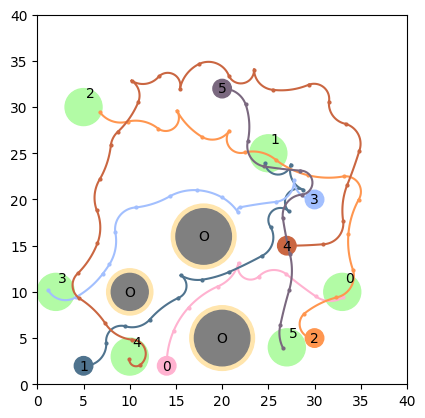

In [3]:
# define a list of colors for trees and paths to use in drawing function
tcol =['y', 'c', 'b', 'g', 'b', 'b']
pcol = ['xkcd:powder pink', 'xkcd:metallic blue', 'xkcd:pastel orange', 'xkcd:pastel blue', 'xkcd:terracotta', 'xkcd:purplish grey']

mprint = MultiRRTPrinter(env, rrts, paths, tcol, pcol)
# setting print_tree to true will show the tree as well
mprint.print_rrt('../media/six_unicycle_prrt_eb.png', print_tree=False)

Start Gathering: 
Gathering for agent number: 1
Gathering for agent number: 2
Gathering for agent number: 3
Gathering for agent number: 4
Gathering for agent number: 5
Gathering for agent number: 6
Done gathering, now animating
Done animating, now saving


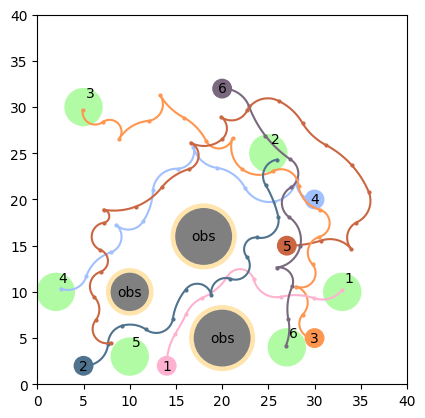

In [ ]:
mprint.print_rrt_animation('../media/six_unicycle_prrt_eb.gif', print_tree=False)

Nodes gather skipped
Nodes gathered
Start Gathering: 
Gathering for agent: 0
Gathering for agent: 1
Gathering for agent: 2
Gathering for agent: 3
Gathering for agent: 4
Gathering for agent: 5
Done gathering, now animating
Done animating, now saving


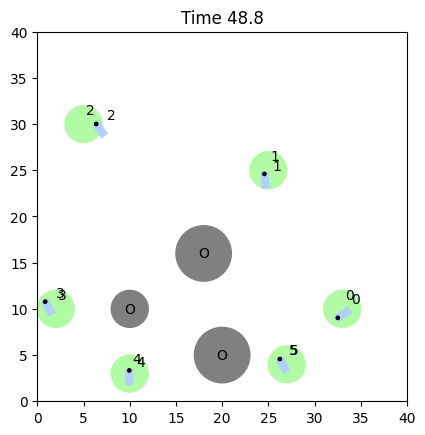

In [4]:
mprint = MultiRRTPrinter(env, rrts, paths, tcol, pcol)
# get high-res paths for each agent 
highres_paths = dict(enumerate([planner.get_high_resolution_path() for planner in rrts]))
# The speed param is the time between each 
# step in the gif (lower number->faster animation speed)
mprint.print_highres_simulation(highres_paths, '../media/six_unicycle_prrt_eb_sim.gif', animation_speed=100)

Display an edge bundle for a Unicycle

In [ ]:
import sys
sys.path.append('../src')

import numpy as np
import math
from Agents import UniCycle

from edge_bundle import EdgeBundle

In [ ]:
# define an agent to use to propagate edges
agent = UniCycle(agent_id = 1, 
                 max_speed = 2.0,
                 max_omega= math.pi/2,
                 radius = 1.0,
                 rng_seed= 77)

start = (5, 5, 0)

# load an edge bundle for the agent, matching the type and speed, etc. 
edge_bundle_file_location = '../edge_bundles/eb_unicycle_edges_100000.npz' 
data = np.load(edge_bundle_file_location)
eb_unicycle = EdgeBundle(data, fix_num_edges=1000)

new_states = []
path_to_nss = []
# iterate through each 
for (action, timestep) in zip(eb_unicycle.actions, eb_unicycle.timesteps):
    new_state, path_to_ns = agent.get_next_state(start, action, timestep, num_steps=math.floor(timestep/0.1))
    new_states.append(new_state)
    path_to_nss.append(path_to_ns)

In [ ]:
# an example edge
eb_unicycle.get_edge(0)

((-0.41006208, -0.43405709),
 1.4,
 array([-0.5429868 ,  0.15739535, -0.60767993]))

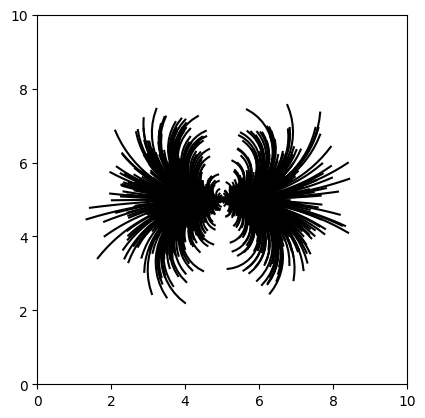

In [ ]:
import matplotlib.pyplot as plt

# helper function to print an edge
def print_tree(ax, path_to_nss, start, col='k'):
    for path in path_to_nss:
        xs = [start[0]] + [i[0] for i in path]
        ys = [start[1]] + [i[1] for i in path]
        ax.plot(xs, ys, color=col, linestyle='-') #, markersize=.1)

# helper function to print all edges in a bundle
def print_rrt():
    fig, ax = plt.subplots() 

    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)

    ax.set_aspect('equal', adjustable='box')

    print_tree(ax, path_to_nss, start)
    
    # ax.legend()
    fig.savefig("../media/unicycle_edge_bundle.png")

print_rrt()

CRRT with 5 Unicycle agents.

In [4]:
import sys
sys.path.append('../src')

import math

from Environments import *
from Agents import UniCycle
from cRRT import CRRT
from printer import  MultiRRTPrinter

In [5]:

obstacles = [CircularObstacle2DTimed(10, 10, 2),
            CircularObstacle2DTimed(18, 16, 3),
            CircularObstacle2DTimed(20, 5, 3)
            ] 
                    
env = SquareEnvironment(40, 40, obstacles)

goal = (33.0, 10.0)
start = (14.0, 2.0, 0)

start2 = (5.0, 2.0, 0)
goal2 = (25.0, 25.0)

start3 = (30.0, 5.0, 0)
goal3 = (5.0, 30.0)

start4 = (30.0, 20.0, 0)
goal4 = (2.0, 10.0)

start5 = (27.0, 15.0, 0)
goal5 = (10.0, 3.0)

num_agents = 5
agents = []
for i in range(num_agents):
    agents.append(UniCycle(agent_id = i+1, 
            max_speed = 2.0,
            max_omega= math.pi/2,
            radius = 1.0,
            rng_seed = 555))
starts = [start, start2, start3, start4, start5]
goals = [goal, goal2, goal3, goal4, goal5]
goal_radii = [0.5 for _ in goals]

# curate list of helper functions for call to CRRT 
# each of these functions must match the agent at the same index
isvalid_funcs = [UniCycle.is_new_node_valid for _ in range(len(agents))]
cost_funcs = [UniCycle.get_cost for _ in range(len(agents))]
random_pt_funcs = [UniCycle.get_random_point for _ in range(len(agents))]
reached_goal_funcs = [UniCycle.agent_reached_goal for _ in range(len(agents))]

In [6]:
# instantiate CRRT obj
crrt = CRRT(agents=agents, 
            starts=starts,
            goals=goals,
            goal_radii=goal_radii,
            env=env,
            max_iter = math.inf, planning_time=math.inf,         
            isvalid_function=isvalid_funcs, 
            cost_function=cost_funcs,
            random_point_function=random_pt_funcs, 
            reached_goal_function = reached_goal_funcs,
            udf_seed = 321, 
            print_logs=True,
            truncate_paths=True
            )
# plan path 
planning_time = crrt.plan_path()

Total Planning Time after 59320 steps: 16.924145936965942


In [4]:
hr_na = crrt.get_high_resolution_path_numpy_array()

In [5]:
crrt.get_costs()

[160.53703810380972,
 157.9064216778691,
 158.24429534046865,
 149.49498609308816,
 150.6478313067]

In [6]:
crrt.get_agent_id_order()

array([1, 2, 3, 4, 5], dtype=int32)

Nodes gather skipped
Nodes gathered


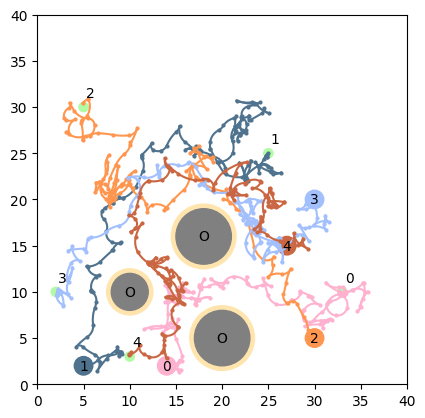

In [7]:
# get path info
path_rrt_nodes, states, controls, timesteps, costs = crrt.get_path()

# define a list of colors for trees and paths to use in drawing function
tcol =['y', 'c', 'b', 'g', 'b', 'b']
pcol = ['xkcd:powder pink', 'xkcd:metallic blue', 'xkcd:pastel orange', 'xkcd:pastel blue', 'xkcd:terracotta', 'xkcd:purplish grey']

mprint = MultiRRTPrinter(env, crrt, path_rrt_nodes, tcol, pcol, joint_states=True)
# setting print_tree to true will show the tree as well
mprint.print_rrt('../media/five_unicycle_crrt.png', print_tree=False)

Start Gathering: 
Gathering for agent number: 1
Gathering for agent number: 2
Gathering for agent number: 3
Gathering for agent number: 4
Gathering for agent number: 5
Done gathering, now animating
Done animating, now saving


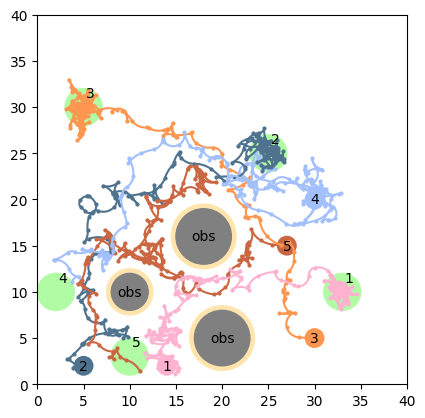

In [ ]:
# setting print_tree to true will show the tree as well
# The speed param is the time between each 
# step in the gif (lower number->faster animation speed)
mprint.print_rrt_animation('../media/five_unicycle_crrt.gif', animation_speed=150, print_tree=False)

Nodes gather skipped
Nodes gathered
Start Gathering: 
Gathering for agent: 0
Gathering for agent: 1
Gathering for agent: 2
Gathering for agent: 3
Gathering for agent: 4
Done gathering, now animating
Done animating, now saving


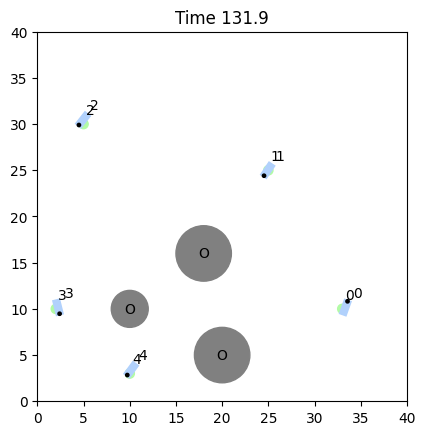

In [9]:
mprint = MultiRRTPrinter(env, crrt, path_rrt_nodes, tcol, pcol, joint_states=True)
# get high-res paths for each agent 
highres_paths = dict(enumerate(crrt.get_high_resolution_paths()))
# The speed param is the time between each 
# step in the gif (lower number->faster animation speed)
mprint.print_highres_simulation(highres_paths, '../media/five_unicycle_crrt_sim.gif', animation_speed=100)

Edge Bundle CRRT with 5 Unicycle agents.

In [15]:
import sys
sys.path.append('../src')

import math

from Environments import *
from Agents import UniCycle
from cRRT_eb import CRRT_EBType2
from printer import  MultiRRTPrinter

In [16]:
# Create some obstacles. For PRRT, each obstacle must 
# have a time element 
obstacles = [CircularObstacle2DTimed(10, 10, 2),
            CircularObstacle2DTimed(18, 16, 3),
            CircularObstacle2DTimed(20, 5, 3)
            ] 

# create an environment with the given obstacles                
env = SquareEnvironment(40, 40, obstacles)
# create a list of unicycle agents 
agents = [UniCycle(agent_id=i,
                 max_speed = 2.0,
                 max_omega= math.pi/2,
                 radius = 1.0,
                 rng_seed=5) for i in range(5)]

# create some start/goals
goal = (33.0, 10.0)
start = (14.0, 2.0, math.pi/2)

start2 = (5.0, 2.0, 0.0)
goal2 = (25.0, 25.0)

start3 = (30.0, 5.0, math.pi)
goal3 = (5.0, 30.0)

start4 = (30.0, 20.0, math.pi)
goal4 = (2.0, 10.0)

start5 = (27.0, 15.0, math.pi)
goal5 = (10.0, 3.0)

start6 = (20.0, 32.0, math.pi)
goal6 = (27.0, 4.0)

# curate lists for call to PRRT 
starts = [start, start2, start3, start4, start5, start6]
goals = [goal, goal2, goal3, goal4, goal5, goal6]
goal_radii = [0.5 for _ in goals]
# each of these functions must match the agent at the same index
isvalid_funcs = [UniCycle.is_new_node_valid for _ in range(len(agents))]
cost_funcs = [UniCycle.get_cost for _ in range(len(agents))]
random_pt_funcs = [UniCycle.get_random_point for _ in range(len(agents))]
reached_goal_funcs = [UniCycle.agent_reached_goal for _ in range(len(agents))]
translate_funcs = [UniCycle.point_translate_function for _ in range(len(agents))]
sort_edges_functions = [UniCycle.sort_edges for _ in range(len(agents))]

# get an edge bundle. 
from edge_bundle import EdgeBundle
import numpy as np
edge_bundle_file_location = '../edge_bundles/eb_unicycle_edges_100000.npz' 
data = np.load(edge_bundle_file_location)
eb_unicycle = EdgeBundle(data, fix_num_edges=1000)
# Each EB must match the agent at the same index, both 
# in type AND IN PARAMETERS (e.x. speed, turning radius, etc)
edge_bundles = [eb_unicycle for _ in range(len(agents))]

In [ ]:
# instantiate CRRT obj
crrt = CRRT_EBType2(agents=agents, 
            starts=starts,
            goals=goals,
            goal_radii=goal_radii,
            edge_bundle=edge_bundles,
            env=env,
            max_iter = math.inf, planning_time=math.inf,         
            isvalid_function=isvalid_funcs, 
            cost_function=cost_funcs,
            random_point_function=random_pt_funcs, 
            reached_goal_function = reached_goal_funcs,
            translate_function=translate_funcs,
            sort_edges_function=sort_edges_functions,
            udf_seed = 61, 
            print_logs=True
            )
# plan path 
planning_time = crrt.plan_path()
planning_time

Agents found goal [4] out of those that have {0: False, 1: False, 2: False, 3: False, 4: False}
Agents found goal [4] out of those that have {0: False, 1: False, 2: False, 3: False, 4: True}
Agents found goal [4] out of those that have {0: False, 1: False, 2: False, 3: False, 4: True}
Agents found goal [4] out of those that have {0: False, 1: False, 2: False, 3: False, 4: True}
Agents found goal [1, 4] out of those that have {0: False, 1: False, 2: False, 3: False, 4: True}
Agents found goal [4] out of those that have {0: False, 1: True, 2: False, 3: False, 4: True}
Agents found goal [4] out of those that have {0: False, 1: True, 2: False, 3: False, 4: True}
Agents found goal [1, 4] out of those that have {0: False, 1: True, 2: False, 3: False, 4: True}
Agents found goal [4] out of those that have {0: False, 1: True, 2: False, 3: False, 4: True}
Agents found goal [1, 4] out of those that have {0: False, 1: True, 2: False, 3: False, 4: True}
Agents found goal [4] out of those that have 

2.9907102584838867

Nodes gather skipped
Nodes gathered


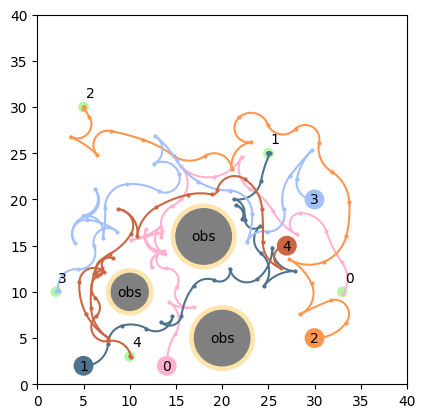

In [ ]:
# get path info
path_rrt_nodes, states, controls, timesteps, costs = crrt.get_path()

# define a list of colors for trees and paths to use in drawing function
tcol =['y', 'c', 'b', 'g', 'b', 'b']
pcol = ['xkcd:powder pink', 'xkcd:metallic blue', 'xkcd:pastel orange', 'xkcd:pastel blue', 'xkcd:terracotta', 'xkcd:purplish grey']

mprint = MultiRRTPrinter(env, crrt, path_rrt_nodes, tcol, pcol, joint_states=True)
# setting print_tree to true will show the tree as well
mprint.print_rrt('../media/five_unicycle_crrt_eb.png', print_tree=False)

Nodes gather skipped
Nodes gathered
Start Gathering: 
Gathering for agent: 0
Gathering for agent: 1
Gathering for agent: 2
Gathering for agent: 3
Gathering for agent: 4
Done gathering, now animating
Done animating, now saving


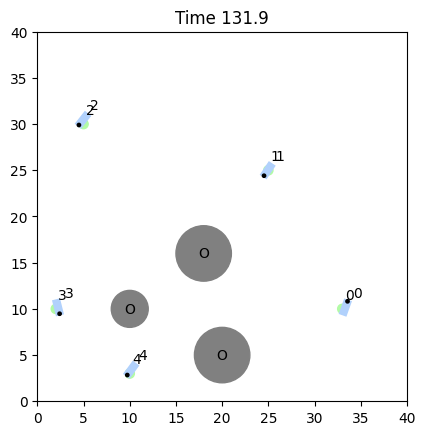

In [ ]:
mprint = MultiRRTPrinter(env, crrt, path_rrt_nodes, tcol, pcol, joint_states=True)
# get high-res paths for each agent 
highres_paths = dict(enumerate(crrt.get_high_resolution_paths()))
# The speed param is the time between each 
# step in the gif (lower number->faster animation speed)
mprint.print_highres_simulation(highres_paths, '../media/five_unicycle_crrt_eb_sim.giffive_unicycle_crrt_eb_sim.gif', animation_speed=50)

KCBS with Vanilla RRT for 5 SOC agents

In [1]:
import sys
sys.path.append('../src')
sys.path.append('../')
sys.path.append('.')

from mapf_env_square_agent_unicycle import *
from Environments import *
from Agents import SecondOrderCar
from constrainedX import *
from kcbs import *

from printer import MultiRRTPrinter
import numpy as np

In [2]:
goal_radius = 1.0

# create goals 
obstacles = [
            CircularObstacle2D(10, 10, 2),
            CircularObstacle2D(16, 25, 3),
            CircularObstacle2D(20, 5, 2),
            CircularObstacle2D(35, 15, 2),
            CircularObstacle2D(30, 34, 4),
            CircularObstacle2D(25, 15, 4),
            CircularObstacle2D(7, 19, 4),
            CircularObstacle2D(16, 16, 2),
            CircularObstacle2D(33, 4, 2),
            CircularObstacle2D(8, 34, 3),
            CircularObstacle2D(20, 32, 2),
            CircularObstacle2D(31, 24, 3),
            ]                      
env = SquareEnvironment(40, 40, obstacles)

num_agents = 5

start1 = (7.0, 5.0, 0, 0, 0)
goal1 = (24.0, 37.0)

start2 = (2.0, 26.0, 0, 0, 0)
goal2 = (37.0, 30.0)

start3 = (28.0, 5.0, 0, 0, 0)
goal3 = (5.0, 29.0)

start4 = (32.0, 18.0, 0, 0, 0)
goal4 = (2.0, 10.0)

start5 = (16.0, 37.0, 0, 0, 0)
goal5 = (36.0, 10.0)

starts = [start1, start2, start3, start4, start5]
goals = [goal1, goal2, goal3, goal4, goal5]


agent_ids = []
agents = []
for agent_id in range(num_agents):
    agent_ids.append(agent_id)
    agents.append(SecondOrderCar(radius=0.3, 
                              agent_id=agent_id, 
                              rng_seed=agent_id*7, 
                              max_phi=np.pi/3, 
                              max_speed=1.0, 
                              max_steering_rate=1.0,
                              wheelbase=0.7))
planners = []
for agent_obj, start, goal in zip(agents, starts, goals):
    planners.append(ConstrainedRRT( 
                                start=start, goal=goal,
                                goal_radius=goal_radius,
                                env = env, agent=agent_obj, 
                                use_fixed_sampling_time=False,
                                sampling_time_step=1.5,
                                minimum_time_step=0.1,
                                max_iter = 10000,
                                planning_time=600.0,
                                isvalid_function=agent_obj.is_new_node_valid,
                                cost_function=agent_obj.get_cost,
                                random_point_function=agent_obj.get_random_point,
                                reached_goal_function = agent_obj.agent_reached_goal,
                                udf_seed = 0, #Will be overwritten by KCBS init
                                debug_flag=False,
                                print_logs=False,
                            ))

In [3]:
kcbs_planner = KCBS(
            env = env,
            agents = agents,
            low_level_planners = planners,
            max_trials = np.inf,
            planning_time = np.inf,
            print_logs=True,
            rng_seed=1234,
            )  
path_found, paths, cost, time = kcbs_planner.plan_multi_agent_paths()

Total Planning Time for agent 0 after 10001 iterations:  3.690302610397339
Path can't be found for agent 0 because goal hasn't been reached!
Total Planning Time for agent 1 after 10001 iterations:  0.4676218032836914
Path can't be found for agent 1 because goal hasn't been reached!
Total Planning Time for agent 2 after 10001 iterations:  0.5518686771392822
Path can't be found for agent 2 because goal hasn't been reached!
Total Planning Time for agent 3 after 10001 iterations:  0.4650230407714844
Path can't be found for agent 3 because goal hasn't been reached!
Total Planning Time for agent 4 after 10001 iterations:  0.4873316287994385
Path can't be found for agent 4 because goal hasn't been reached!
*************************************
Current iteration:  0  at  6.282205820083618  seconds.
Replanning the path...
Total Planning Time for agent 0 after 5946 iterations:  0.3229689598083496
Replanning the path...
Total Planning Time for agent 1 after 8417 iterations:  0.4333348274230957
Re

Nodes gather skipped
Nodes gathered


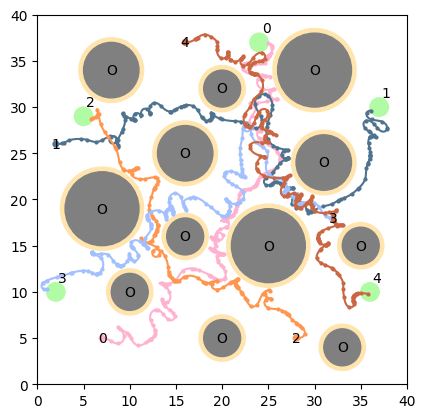

In [4]:
planner_list = [planners[i] for i in range(num_agents)]

path_node = kcbs_planner.path_cbs_node
dict_paths = {}
ids_list = []
for i in range(num_agents):
    t = path_node.agent_trees[i]
    planners[i].tree = t[0]
    planners[i]._node_matrix = t[1]
    goal_id = next(reversed(t[0]._node))
    planners[i].goal_node_id = goal_id
    planners[i].path_found = True
    dict_paths[i] = planners[i].get_high_resolution_path()
    ids, states, controls, timesteps = planners[i].get_path()
    ids_list.append(ids)


# define a list of colors for trees and paths to use in drawing function
tcol =['y', 'c', 'b', 'g', 'b', 'b']
pcol = ['xkcd:powder pink', 'xkcd:metallic blue', 'xkcd:pastel orange', 'xkcd:pastel blue', 'xkcd:terracotta', 'xkcd:purplish grey']
mprint = MultiRRTPrinter(env, planner_list, ids_list, tcol, pcol)
mprint.print_rrt('../media/five_soc_kcbs.png', print_tree=False)

Edge Bundle KCBS with 5 Unicycle agents.

In [1]:
import sys
sys.path.append('../src')
sys.path.append('../')
sys.path.append('.')

from mapf_env_square_agent_unicycle import *
from Environments import *

from printer import MultiRRTPrinter

In [2]:
goal_radius = 1.0

# create goals 
obstacles = [
            CircularObstacle2D(10, 10, 2),
            CircularObstacle2D(16, 25, 3),
            CircularObstacle2D(20, 5, 2),
            CircularObstacle2D(35, 15, 2),
            CircularObstacle2D(30, 34, 4),
            CircularObstacle2D(25, 15, 4),
            CircularObstacle2D(7, 19, 4),
            CircularObstacle2D(16, 16, 2),
            CircularObstacle2D(33, 4, 2),
            CircularObstacle2D(8, 34, 3),
            CircularObstacle2D(20, 32, 2),
            CircularObstacle2D(31, 24, 3),
            ]                      
env = SquareEnvironment(40, 40, obstacles)

num_agents = 5

start1 = (7.0, 5.0, 0)
goal1 = (24.0, 37.0)

start2 = (2.0, 26.0, 0)
goal2 = (37.0, 30.0)

start3 = (28.0, 5.0, 0)
goal3 = (5.0, 29.0)

start4 = (32.0, 18.0, 0)
goal4 = (2.0, 10.0)

start5 = (16.0, 37.0, 0)
goal5 = (36.0, 10.0)

starts = [start1, start2, start3, start4, start5]
goals = [goal1, goal2, goal3, goal4, goal5]

agent_ids = []
agents = []
for agent_id in range(num_agents):
    agent_ids.append(agent_id)
    agents.append(get_unicycle_agent(agent_id))

planners = []
planner_function = get_eb_rrt_planner
for i in range(num_agents):
    planners.append(planner_function(starts[i],goals[i],goal_radius,agents[i],env, edge_bundle_file_location='../edge_bundles/eb_unicycle_edges_100000.npz'))

# s = np.random.randint(0, 1000)
# print("RNG Seed: ", s)
s = 42  
kcbs_planner = KCBS(
                    env = env,
                    agents = agents,
                    low_level_planners = planners,
                    max_trials = 50,
                    planning_time = 600.0,
                    rng_seed = s,
                    print_logs=True,
                    debug_flag=True
                    )
path_found, paths, cost, delta_t = kcbs_planner.plan_multi_agent_paths()

Total Planning Time for agent 0 after 218 iterations:  2.565490961074829
Total Planning Time for agent 1 after 347 iterations:  0.05027151107788086
Total Planning Time for agent 2 after 375 iterations:  0.053009748458862305
Total Planning Time for agent 3 after 72 iterations:  0.009753227233886719
Total Planning Time for agent 4 after 49 iterations:  0.0067441463470458984
*************************************
Current iteration:  0  at  3.31986403465271  seconds.
Popped node with ID:  1
Popped node with cost:  277.55616277290306
Popped node with num conflicts per agent:  [0, 0, 0, 0, 0]
Popped node with paths lengths:  [390, 582, 484, 326, 321]
Popped node with trees lengths:  [210, 348, 374, 74, 51]
Popped node with path costs:  [53.84251134282079, 67.53776266144556, 71.89089225784949, 43.75203212852181, 40.53296438226541]
Popped node with total cost:  277.55616277290306
Collision between agents  0  and  2  at time  [34.  34.1 34.2 34.3 34.4 34.5 34.6 34.7 34.8 34.9]
New first agent co

Nodes gather skipped
Nodes gathered


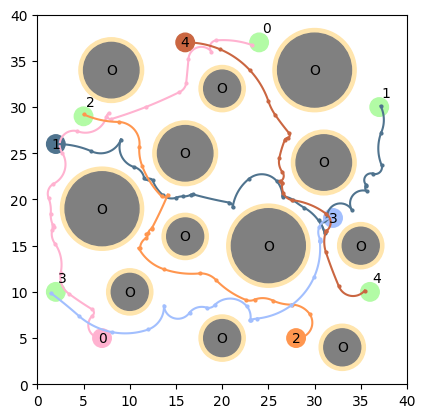

In [3]:
planner_list = [planners[i] for i in range(num_agents)]

path_node = kcbs_planner.path_cbs_node
dict_paths = {}
ids_list = []
for i in range(num_agents):
    t = path_node.agent_trees[i]
    planners[i].tree = t[0]
    planners[i]._node_matrix = t[1]
    goal_id = next(reversed(t[0]._node))
    planners[i].goal_node_id = goal_id
    planners[i].path_found = True
    dict_paths[i] = planners[i].get_high_resolution_path()
    ids, states, controls, timesteps = planners[i].get_path()
    ids_list.append(ids)


# define a list of colors for trees and paths to use in drawing function
tcol =['y', 'c', 'b', 'g', 'b', 'b']
pcol = ['xkcd:powder pink', 'xkcd:metallic blue', 'xkcd:pastel orange', 'xkcd:pastel blue', 'xkcd:terracotta', 'xkcd:purplish grey']
mprint = MultiRRTPrinter(env, planner_list, ids_list, tcol, pcol)
mprint.print_rrt('../media/five_unicycle_kcbs_eb.png', print_tree=False)


Start Gathering: 
Gathering for agent: 0
Gathering for agent: 1
Gathering for agent: 2
Gathering for agent: 3
Gathering for agent: 4
Done gathering, now animating
Done animating, now saving


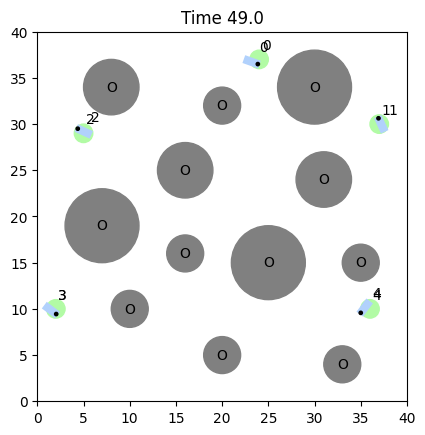

In [4]:
# The speed param is the time between each 
# step in the gif (lower number->faster animation speed)
mprint.print_highres_simulation(dict_paths, "../media/five_unicycle_kcbs_rrt_eb_sim.gif", animation_speed=50)

Kino-TI KCBS with 5 SOC agents.


In [3]:
import sys
sys.path.append('../src')
sys.path.append('../')
sys.path.append('.')

from mapf_env_square_agent_unicycle import *
from Environments import *
from Agents import SecondOrderCar
from edge_bundle import EdgeBundle
from constrainedX import *
from kcbs import *
from kd_tree_second_order_car import VPhiTree

from printer import MultiRRTPrinter
import numpy as np

In [8]:
goal_radius = 1.0

# create goals 
obstacles = [
            CircularObstacle2D(10, 10, 2),
            CircularObstacle2D(16, 25, 3),
            CircularObstacle2D(20, 5, 2),
            CircularObstacle2D(35, 15, 2),
            CircularObstacle2D(30, 34, 4),
            CircularObstacle2D(25, 15, 4),
            CircularObstacle2D(7, 19, 4),
            CircularObstacle2D(16, 16, 2),
            CircularObstacle2D(33, 4, 2),
            CircularObstacle2D(8, 34, 3),
            CircularObstacle2D(20, 32, 2),
            CircularObstacle2D(31, 24, 3),
            ]                      
env = SquareEnvironment(40, 40, obstacles)

num_agents = 5

start1 = (7.0, 5.0, 0, 0, 0)
goal1 = (24.0, 37.0)

start2 = (2.0, 26.0, 0, 0, 0)
goal2 = (37.0, 30.0)

start3 = (28.0, 5.0, 0, 0, 0)
goal3 = (5.0, 29.0)

start4 = (32.0, 18.0, 0, 0, 0)
goal4 = (2.0, 10.0)

start5 = (16.0, 37.0, 0, 0, 0)
goal5 = (36.0, 10.0)

starts = [start1, start2, start3, start4, start5]
goals = [goal1, goal2, goal3, goal4, goal5]

data = np.load('../edge_bundles/eb_second_order_car_kinodynamic_TI_edges_100000.npz', allow_pickle=True)
kino_ti_edge_bundle = EdgeBundle(data, fix_num_edges=30000, use_all_edges=False)
edge_ids = np.arange(kino_ti_edge_bundle.num_edges, dtype=np.int64)
speeds = kino_ti_edge_bundle.start_states[:, 3]  # v
phis = kino_ti_edge_bundle.start_states[:, 4]   # phi
v_scale = 1.0
phi_scale = np.pi/3
kd_tree_ti_edge_bundle = VPhiTree(speeds, phis, ids=edge_ids, 
            v_scale=v_scale, phi_scale=phi_scale)

agent_ids = []
agents = []
for agent_id in range(num_agents):
    agent_ids.append(agent_id)
    agents.append(SecondOrderCar(radius=0.3, 
                              agent_id=agent_id, 
                              rng_seed=agent_id*7, 
                              max_phi=np.pi/3, 
                              max_speed=1.0, 
                              max_steering_rate=1.0,
                              wheelbase=0.7))
planners = []
for agent_obj, start, goal in zip(agents, starts, goals):
    planners.append(ConstrainedKinoTIEBRRT( 
                                start=start, goal=goal,
                                goal_radius=goal_radius,
                                env = env, agent=agent_obj, 
                                edge_bundle = kino_ti_edge_bundle,
                                use_fixed_sampling_time=False,
                                sampling_time_step=1.5,
                                minimum_time_step=0.1,
                                max_iter = 10000,
                                planning_time=600.0,
                                isvalid_function=agent_obj.is_new_node_valid,
                                cost_function=agent_obj.get_cost,
                                random_point_function=agent_obj.get_random_point,
                                reached_goal_function = agent_obj.agent_reached_goal,
                                translate_function = agent_obj.kd_tree_point_translate_function,
                                sort_edges_function=agent_obj.sort_kd_tree_edges,
                                max_num_edges_per_node=1000,
                                num_skip_edges= 100,
                                num_random_edges= 10,
                                eb_kd_tree = kd_tree_ti_edge_bundle,
                                get_eb_kd_tree_query=agent_obj.get_eb_kd_tree_query,
                                kd_tree_delta_radius=0.1,
                                udf_seed = 0, #Will be overwritten by KCBS init
                                debug_flag=False,
                                print_logs=False,
                            ))

In [9]:
kcbs_planner = KCBS(
            env = env,
            agents = agents,
            low_level_planners = planners,
            max_trials = np.inf,
            planning_time = np.inf,
            print_logs=True,
            rng_seed=1234,
            )  
path_found, paths, cost, time = kcbs_planner.plan_multi_agent_paths()

Total Planning Time for agent 0 after 284 iterations:  4.095441102981567
Total Planning Time for agent 1 after 3250 iterations:  0.27724242210388184
Total Planning Time for agent 2 after 971 iterations:  0.0731198787689209
Total Planning Time for agent 3 after 396 iterations:  0.04054546356201172
Total Planning Time for agent 4 after 912 iterations:  0.07640981674194336
*************************************
Current iteration:  0  at  4.99219536781311  seconds.
Total Planning Time for agent 0 after 1298 iterations:  0.09528636932373047
Total Planning Time for agent 1 after 1288 iterations:  0.12071347236633301
*************************************
Current iteration:  1  at  6.604626655578613  seconds.
Total Planning Time for agent 1 after 359 iterations:  0.04134011268615723
Total Planning Time for agent 2 after 858 iterations:  0.0795595645904541
*************************************
Current iteration:  2  at  6.7262914180755615  seconds.


Nodes gather skipped
Nodes gathered


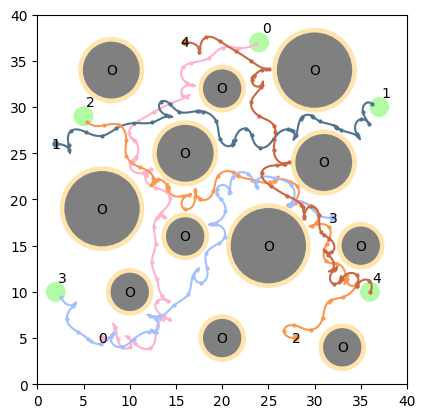

In [19]:
planner_list = [planners[i] for i in range(num_agents)]

path_node = kcbs_planner.path_cbs_node
dict_paths = {}
ids_list = []
for i in range(num_agents):
    t = path_node.agent_trees[i]
    planners[i].tree = t[0]
    planners[i]._node_matrix = t[1]
    goal_id = next(reversed(t[0]._node))
    planners[i].goal_node_id = goal_id
    planners[i].path_found = True
    dict_paths[i] = planners[i].get_high_resolution_path()
    ids, states, controls, timesteps = planners[i].get_path()
    ids_list.append(ids)


# define a list of colors for trees and paths to use in drawing function
tcol =['y', 'c', 'b', 'g', 'b', 'b']
pcol = ['xkcd:powder pink', 'xkcd:metallic blue', 'xkcd:pastel orange', 'xkcd:pastel blue', 'xkcd:terracotta', 'xkcd:purplish grey']
mprint = MultiRRTPrinter(env, planner_list, ids_list, tcol, pcol)
mprint.print_rrt('../media/five_soc_kcbs_kino_ti_eb.png', print_tree=False)

Start Gathering: 
Gathering for agent: 0
Gathering for agent: 1
Gathering for agent: 2
Gathering for agent: 3
Gathering for agent: 4
Done gathering, now animating
Done animating, now saving


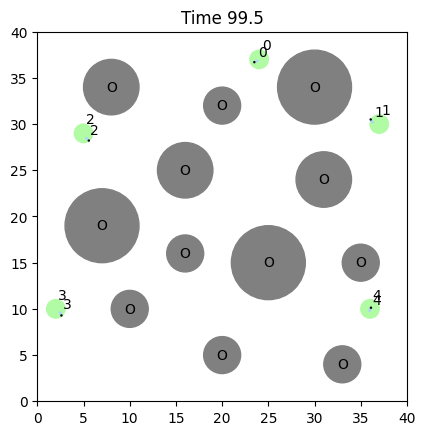

In [17]:
# The speed param is the time between each 
# step in the gif (lower number->faster animation speed)
mprint.print_highres_simulation(dict_paths, "../media/five_soc_kcbs_rrt_kino-ti-eb_sim.gif", animation_speed=50)

prioritized planning with SST

In [ ]:
import sys
sys.path.append('../src')


from prioritized_planning import PrioritizedPlaning
from Environments import SquareEnvironment, CircularObstacle2D
from Agents import SecondOrderCar, UniCycle
from rrt import RRT
from sst import SST
import numpy as np


from printer import MultiRRTPrinter

In [2]:
goal_radius = 1.0

# create goals 
obstacles = [CircularObstacle2D(10, 10, 2),
            CircularObstacle2D(18, 16, 3),
            CircularObstacle2D(20, 5, 3)
            ]                 
env = SquareEnvironment(40, 40, obstacles)

num_agents = 6

# create some start/goals
goal = (33.0, 10.0)
start = (14.0, 2.0, np.pi/2, 0,0)

start2 = (5.0, 2.0, 0.0,0,0)
goal2 = (25.0, 25.0)

start3 = (30.0, 5.0, np.pi,0,0)
goal3 = (5.0, 30.0)

start4 = (30.0, 20.0, np.pi,0,0)
goal4 = (2.0, 10.0)

start5 = (27.0, 15.0, np.pi,0,0)
goal5 = (10.0, 3.0)

start6 = (20.0, 32.0, np.pi,0,0)
goal6 = (27.0, 4.0)

starts = [start, start2, start3, start4, start5, start6]
goals = [goal, goal2, goal3, goal4, goal5, goal6]

planners = []
agents = []
for agent_id in range(num_agents):
    agent = SecondOrderCar(agent_id = agent_id, 
                       max_speed = 2.0,
                       max_acceleration = 1.0,
                       max_phi = np.pi/3,
                       max_steering_rate = 0.5,
                       radius = 1.0,
                       wheelbase = 0.7,
                       rng_seed=42
                       )
    agents.append(agent)
    planners.append(SST( 
            start=starts[agent_id], goal=goals[agent_id],
            goal_radius=goal_radius, 
            env = env, agent=agent,
            sampling_time_step=1.5,
            minimum_time_step=0.1,
            max_iter = np.inf,
            planning_time=300.0,         
            isvalid_function=agent.is_new_node_valid,
            cost_function=agent.get_cost,
            random_point_function=agent.get_random_point, 
            reached_goal_function = agent.agent_reached_goal,
            udf_seed = 23 + 7*agent_id,
            print_logs=True,
            # debug_flag=True,
            best_near_radius=5.0
           ))
    
PrioritizedPlaning.plan_multi(planners=planners, planning_time=300, print_logs=True)

Planning for agent 0 with id 0
Total Planning Time for agent 0 after 745 iterations:  3.2249436378479004
Planning for agent 1 with id 1
Total Planning Time for agent 1 after 4086 iterations:  0.15352511405944824
Planning for agent 2 with id 2
Total Planning Time for agent 2 after 1395 iterations:  0.06368899345397949
Planning for agent 3 with id 3
Total Planning Time for agent 3 after 2815 iterations:  0.13606023788452148
Planning for agent 4 with id 4
Total Planning Time for agent 4 after 4411 iterations:  0.2176804542541504
Planning for agent 5 with id 5
Total Planning Time for agent 5 after 4977 iterations:  0.23642277717590332


(True, 4.101601839065552)

Nodes gather skipped
Nodes gathered
Start Gathering: 
Gathering for agent: 0
Gathering for agent: 1
Gathering for agent: 2
Gathering for agent: 3
Gathering for agent: 4
Gathering for agent: 5
Done gathering, now animating
Done animating, now saving


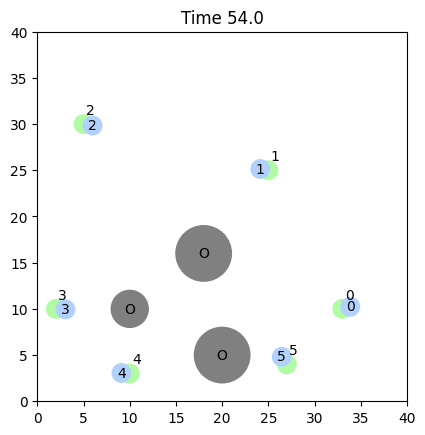

In [ ]:
mprint = MultiRRTPrinter(env, planners, [],[],[])

def enumerate_range(xs, start=0, step=.1):
    res = {}
    for x in xs:
        res[start] = x
        start += step
        start = round(start, 1)
    return res
highres_paths = (enumerate_range(planner.get_high_resolution_path_numpy_array()) for planner in planners)

# The speed param is the time between each 
# step in the gif (lower number->faster animation speed)
mprint.print_highres_simulation(dict(enumerate(highres_paths)), "../media/six_soc_prioritized_sst_sim.gif", animation_speed=50)

prioritized planning with SST w/Kino EB

In [1]:
import sys
sys.path.append('../src')


from prioritized_planning import PrioritizedPlaning
from Environments import SquareEnvironment, CircularObstacle2D
from Agents import UniCycle
import numpy as np
from kinodynamic_TI_eb_sst import * 
from edge_bundle import EdgeBundle, GenerateEdgeBundle
from kd_tree_unicycle import CircularAngleIndexNumba


from printer import MultiRRTPrinter

In [2]:
goal_radius = 1.0

# create goals 
obstacles = [CircularObstacle2D(10, 10, 2),
            CircularObstacle2D(18, 16, 3),
            CircularObstacle2D(20, 5, 3)
            ]                 
env = SquareEnvironment(40, 40, obstacles)

num_agents = 6

# create some start/goals
goal = (33.0, 10.0)
start = (14.0, 2.0, np.pi/2)

start2 = (5.0, 2.0, 0.0)
goal2 = (25.0, 25.0)

start3 = (30.0, 5.0, np.pi)
goal3 = (5.0, 30.0)

start4 = (30.0, 20.0, np.pi)
goal4 = (2.0, 10.0)

start5 = (27.0, 15.0, np.pi)
goal5 = (10.0, 3.0)

start6 = (20.0, 32.0, np.pi)
goal6 = (27.0, 4.0)

starts = [start, start2, start3, start4, start5, start6]
goals = [goal, goal2, goal3, goal4, goal5, goal6]

edge_bundle_file_location = '../edge_bundles/eb_unicycle_kinodynamic_TI_edges_100000.npz'
data = np.load(edge_bundle_file_location)
kino_TI_eb_unicycle = EdgeBundle(data, fix_num_edges=30000, use_all_edges=False)
edge_ids = np.arange(kino_TI_eb_unicycle.num_edges, dtype=np.int64)
thetas = kino_TI_eb_unicycle.start_states[:, 2]  # heading angle θ
kd_tree_TI_eb_unicycle = CircularAngleIndexNumba(thetas, ids=edge_ids)

planners = []
agents = []
for agent_id in range(num_agents):
    agent = UniCycle(agent_id = agent_id, 
                 max_speed = 2.0,
                 max_omega= np.pi/2,
                 radius = 1.0,
                 rng_seed= 29 + 7*agent_id)
    agents.append(agent)
    planners.append(EB_SST( 
            start=starts[agent_id], goal=goals[agent_id],
            goal_radius=goal_radius,
            env = env, agent=agent, 
            edge_bundle = kino_TI_eb_unicycle,
            use_fixed_sampling_time=False,
            sampling_time_step=1.5,
            minimum_time_step=0.1,
            max_iter = np.inf,
            num_random_edges= 10,
            num_skip_edges= 100,
            planning_time=30.0,
            isvalid_function=agent.is_new_node_valid,
            cost_function=agent.get_cost,
            random_point_function=agent.get_random_point,
            reached_goal_function = agent.agent_reached_goal,
            translate_function = agent.kd_tree_point_translate_function,
            sort_edges_function=agent.sort_kd_tree_edges,
            eb_kd_tree=kd_tree_TI_eb_unicycle,
            get_eb_kd_tree_query=agent.get_eb_kd_tree_query,
            max_num_edges_per_node=1000,
            udf_seed = 11 + 7*agent_id,
            debug_flag=False,
            print_logs=True,
            best_near_radius=5.0,
            prune_radius=0.1
            ))
    
PrioritizedPlaning.plan_multi(planners=planners, planning_time=10, print_logs=True)

Planning for agent 0 with id 0


/mnt/5AA62DE65C90E7CA/classes/6519/mrmp_with_kite_extend/sandbox/../src/kd_tree_unicycle.py:18: NumbaExperimentalFeatureWarning: First-class function type feature is experimental
  return lo


Total Planning Time for agent 0 after 638 iterations:  2.9978232383728027
Planning for agent 1 with id 1
Total Planning Time for agent 1 after 4898 iterations:  0.5564215183258057
Planning for agent 2 with id 2
Total Planning Time for agent 2 after 543 iterations:  0.05626320838928223
Planning for agent 3 with id 3
Total Planning Time for agent 3 after 6664 iterations:  0.7792377471923828
Planning for agent 4 with id 4
Total Planning Time for agent 4 after 3541 iterations:  0.4147038459777832
Planning for agent 5 with id 5
Total Planning Time for agent 5 after 922 iterations:  0.09686875343322754


(True, 4.978654384613037)

Nodes gather skipped
Nodes gathered
Start Gathering: 
Gathering for agent: 0
Gathering for agent: 1
Gathering for agent: 2
Gathering for agent: 3
Gathering for agent: 4
Gathering for agent: 5
Done gathering, now animating
Done animating, now saving


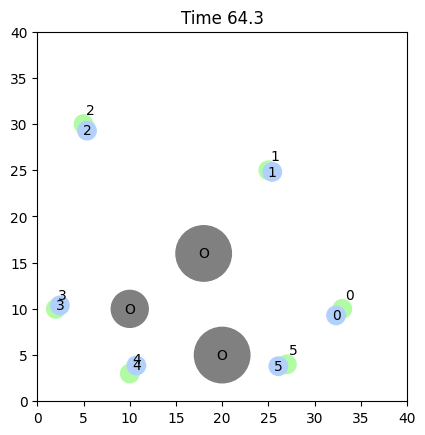

In [3]:
mprint = MultiRRTPrinter(env, planners, [],[],[])

def enumerate_range(xs, start=0, step=.1):
    res = {}
    for x in xs:
        res[start] = x
        start += step
        start = round(start, 1)
    return res
highres_paths = (enumerate_range(planner.get_high_resolution_path_numpy_array()) for planner in planners)

# The speed param is the time between each 
# step in the gif (lower number->faster animation speed)
mprint.print_highres_simulation(dict(enumerate(highres_paths)), "../media/six_unicycle_prioritized_sst_kino_ti_sim.gif", animation_speed=50)

prioritized planning with RRT w/Kino EB

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt

from prioritized_planning import PrioritizedPlaning
from Environments import SquareEnvironment, CircularObstacle2D
from Agents import UniCycle
from kinodynamic_TI_eb_rrt import * 
from edge_bundle import EdgeBundle
from printer import *
from kd_tree_unicycle import CircularAngleIndexNumba

In [2]:
goal_radius = 1.0

# create goals 
obstacles = [CircularObstacle2D(10, 10, 2),
            CircularObstacle2D(18, 16, 3),
            CircularObstacle2D(20, 5, 3)
            ]                 
env = SquareEnvironment(40, 40, obstacles)

num_agents = 6

# create some start/goals
goal = (33.0, 10.0)
start = (14.0, 2.0, np.pi/2)

start2 = (5.0, 2.0, 0.0)
goal2 = (25.0, 25.0)

start3 = (30.0, 5.0, np.pi)
goal3 = (5.0, 30.0)

start4 = (30.0, 20.0, np.pi)
goal4 = (2.0, 10.0)

start5 = (27.0, 15.0, np.pi)
goal5 = (10.0, 3.0)

start6 = (20.0, 32.0, np.pi)
goal6 = (27.0, 4.0)

starts = [start, start2, start3, start4, start5, start6]
goals = [goal, goal2, goal3, goal4, goal5, goal6]

edge_bundle_file_location = '../edge_bundles/eb_unicycle_kinodynamic_TI_edges_100000.npz'
data = np.load(edge_bundle_file_location)
kino_TI_eb_unicycle = EdgeBundle(data, fix_num_edges=30000, use_all_edges=False)
edge_ids = np.arange(kino_TI_eb_unicycle.num_edges, dtype=np.int64)
thetas = kino_TI_eb_unicycle.start_states[:, 2]  # heading angle θ
kd_tree_TI_eb_unicycle = CircularAngleIndexNumba(thetas, ids=edge_ids)

planners = []
agents = []
for agent_id in range(num_agents):
    agent = UniCycle(agent_id = agent_id, 
                 max_speed = 2.0,
                 max_omega= np.pi/2,
                 radius = 1.0,
                 rng_seed= 29 + 7*agent_id)
    agents.append(agent)
    planners.append(KinoTIEBRRT( 
            start=starts[agent_id], goal=goals[agent_id],
            goal_radius=goal_radius,
            env = env, agent=agent, 
            edge_bundle = kino_TI_eb_unicycle,
            use_fixed_sampling_time=True,
            sampling_time_step=1.5,
            minimum_time_step=0.1,
            max_iter = 10000,
            planning_time=600.0,
            isvalid_function=agent.is_new_node_valid,
            cost_function=agent.get_cost,
            random_point_function=agent.get_random_point,
            reached_goal_function = agent.agent_reached_goal,
            translate_function = agent.kd_tree_point_translate_function,
            sort_edges_function=agent.sort_kd_tree_edges,
            max_num_edges_per_node=1000,
            num_skip_edges= 100,
            num_random_edges= 10,
            eb_kd_tree=kd_tree_TI_eb_unicycle,
            get_eb_kd_tree_query=agent.get_eb_kd_tree_query,
            kd_tree_delta_radius=0.5,
            udf_seed = 11 + 7*agent_id,
            debug_flag=False,
            print_logs=False,
            ))
    
PrioritizedPlaning.plan_multi(planners=planners, planning_time=100, print_logs=True)

Planning for agent 0 with id 0


/mnt/5AA62DE65C90E7CA/classes/6519/mrmp_with_kite_extend/sandbox/../src/kd_tree_unicycle.py:18: NumbaExperimentalFeatureWarning: First-class function type feature is experimental
  return lo


Planning for agent 1 with id 1
Planning for agent 2 with id 2
Planning for agent 3 with id 3
Planning for agent 4 with id 4
Planning for agent 5 with id 5


(True, 2.861773729324341, 280.58560391064316)

Nodes gather skipped
Nodes gathered
Start Gathering: 
Gathering for agent: 0
Gathering for agent: 1
Gathering for agent: 2
Gathering for agent: 3
Gathering for agent: 4
Gathering for agent: 5
Done gathering, now animating
Done animating, now saving


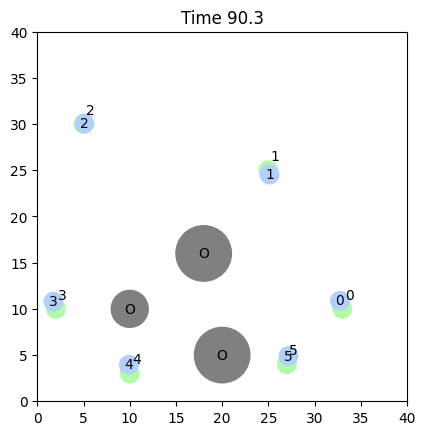

In [6]:
mprint = MultiRRTPrinter(env, planners, [],[],[])

def enumerate_range(xs, start=0, step=.1):
    res = {}
    for x in xs:
        res[start] = x
        start += step
        start = round(start, 1)
    return res
highres_paths = (enumerate_range(planner.get_high_resolution_path_numpy_array()) for planner in planners)

# The speed param is the time between each 
# step in the gif (lower number->faster animation speed)
mprint.print_highres_simulation(dict(enumerate(highres_paths)), "../media/six_unicycle_prioritized_rrt_kino_ti_sim.gif", animation_speed=50)

cRRT with Kino-TI Edge Bundles

In [8]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt

from Environments import SquareEnvironment, CircularObstacle2D
from Agents import UniCycle
from kinodynamic_TI_eb_crrt import * 
from edge_bundle import EdgeBundle
from printer import *
from kd_tree_unicycle import CircularAngleIndexNumba

In [9]:
goal_radius = 1.0

# create goals 
obstacles = [CircularObstacle2D(10, 10, 2),
            CircularObstacle2D(18, 16, 3),
            CircularObstacle2D(20, 5, 3)
            ]                 
env = SquareEnvironment(40, 40, obstacles)

num_agents = 6

# create some start/goals
goal = (33.0, 10.0)
start = (14.0, 2.0, np.pi/2)

start2 = (5.0, 2.0, 0.0)
goal2 = (25.0, 25.0)

start3 = (30.0, 5.0, np.pi)
goal3 = (5.0, 30.0)

start4 = (30.0, 20.0, np.pi)
goal4 = (2.0, 10.0)

start5 = (27.0, 15.0, np.pi)
goal5 = (10.0, 3.0)

start6 = (20.0, 32.0, np.pi)
goal6 = (27.0, 4.0)

starts = [start, start2, start3, start4, start5, start6]
goals = [goal, goal2, goal3, goal4, goal5, goal6]
goal_radii = [goal_radius for _ in range(num_agents)]

edge_bundle_file_location = '../edge_bundles/eb_unicycle_kinodynamic_TI_edges_100000.npz'
data = np.load(edge_bundle_file_location)
kino_TI_eb_unicycle = EdgeBundle(data, fix_num_edges=30000, use_all_edges=False)
edge_ids = np.arange(kino_TI_eb_unicycle.num_edges, dtype=np.int64)
thetas = kino_TI_eb_unicycle.start_states[:, 2]  # heading angle θ
kd_tree_TI_eb_unicycle = CircularAngleIndexNumba(thetas, ids=edge_ids)

isvalid_funcs = []
cost_funcs = []
random_pt_funcs = []
reached_goal_funcs = []
translate_funcs = []
sort_edges_functions = []
edge_bundles = []
eb_kd_trees = []
get_eb_kd_tree_query_funcs = []

agents = []
for agent_id in range(num_agents):
    agent = UniCycle(agent_id = agent_id, 
                 max_speed = 2.0,
                 max_omega= np.pi/2,
                 radius = 1.0,
                 rng_seed= 29 + 7*agent_id)
    agents.append(agent)
    isvalid_funcs.append(agent.is_new_node_valid)
    cost_funcs.append(agent.get_cost)
    random_pt_funcs.append(agent.get_random_point)
    reached_goal_funcs.append(agent.agent_reached_goal)
    translate_funcs.append(agent.kd_tree_point_translate_function)
    sort_edges_functions.append(agent.sort_kd_tree_edges)
    edge_bundles.append(kino_TI_eb_unicycle)
    eb_kd_trees.append(kd_tree_TI_eb_unicycle)
    get_eb_kd_tree_query_funcs.append(agent.get_eb_kd_tree_query)

In [11]:
# instantiate CRRT obj
crrt = KinoTIEBCRRT(agents=agents, 
            starts=starts,
            goals=goals,
            goal_radii=goal_radii,
            edge_bundle=edge_bundles,
            env=env,
            max_iter = math.inf, planning_time=math.inf,         
            isvalid_function=isvalid_funcs, 
            cost_function=cost_funcs,
            random_point_function=random_pt_funcs, 
            reached_goal_function = reached_goal_funcs,
            translate_function=translate_funcs,
            sort_edges_function=sort_edges_functions,
            udf_seed = 61, 
            print_logs=True,
            eb_kd_trees=eb_kd_trees,
            get_eb_kd_tree_query_funcs=get_eb_kd_tree_query_funcs,
            max_num_edges_per_node=1000,
            num_skip_edges= 100,
            num_random_edges= 10,
            kd_tree_delta_radius=0.5,
            truncate_paths=True
            )
# plan path 
planning_time = crrt.plan_path()
planning_time

Agents found goal [0] out of those that have {0: False, 1: False, 2: False, 3: False, 4: False, 5: False}
Agents found goal [0] out of those that have {0: True, 1: False, 2: False, 3: False, 4: False, 5: False}
Agents found goal [0] out of those that have {0: True, 1: False, 2: False, 3: False, 4: False, 5: False}
Agents found goal [0] out of those that have {0: True, 1: False, 2: False, 3: False, 4: False, 5: False}
Agents found goal [0] out of those that have {0: True, 1: False, 2: False, 3: False, 4: False, 5: False}
Agents found goal [0] out of those that have {0: True, 1: False, 2: False, 3: False, 4: False, 5: False}
Agents found goal [0] out of those that have {0: True, 1: False, 2: False, 3: False, 4: False, 5: False}
Agents found goal [0] out of those that have {0: True, 1: False, 2: False, 3: False, 4: False, 5: False}
Agents found goal [0] out of those that have {0: True, 1: False, 2: False, 3: False, 4: False, 5: False}
Agents found goal [0] out of those that have {0: True,

0.4674830436706543

Nodes gather skipped
Nodes gathered
Start Gathering: 
Gathering for agent: 0
Gathering for agent: 1
Gathering for agent: 2
Gathering for agent: 3
Gathering for agent: 4
Gathering for agent: 5
Done gathering, now animating
Done animating, now saving


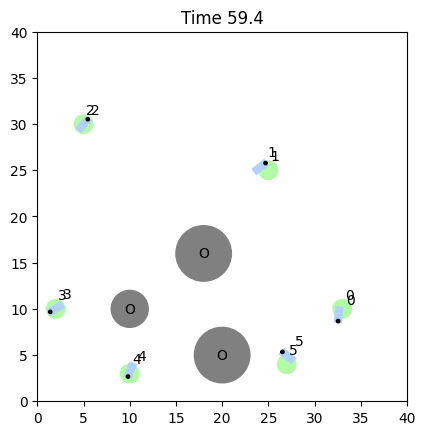

In [7]:
# get path info
path_rrt_nodes, states, controls, timesteps, costs = crrt.get_path()

# define a list of colors for trees and paths to use in drawing function
tcol =['y', 'c', 'b', 'g', 'b', 'b']
pcol = ['xkcd:powder pink', 'xkcd:metallic blue', 'xkcd:pastel orange', 'xkcd:pastel blue', 'xkcd:terracotta', 'xkcd:purplish grey']

mprint = MultiRRTPrinter(env, crrt, path_rrt_nodes, tcol, pcol, joint_states=True)
# get high-res paths for each agent 
highres_paths = dict(enumerate(crrt.get_high_resolution_paths()))
# The speed param is the time between each 
# step in the gif (lower number->faster animation speed)
mprint.print_highres_simulation(highres_paths, '../media/five_unicycle_crrt_kinoti_eb_sim.gif', animation_speed=50)

Constrained CRRT testing

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt

from Environments import SquareEnvironment, CircularObstacle2D
from Agents import UniCycle
from ConstrainedCRRT import ConstrainedKinoTIEBCRRT, check_collisions_2d_constrained 
from edge_bundle import EdgeBundle
from printer import *
from kd_tree_unicycle import CircularAngleIndexNumba

In [2]:
goal_radius = 1.0

# create goals 
obstacles = [CircularObstacle2D(10, 10, 2),
            CircularObstacle2D(18, 16, 3),
            CircularObstacle2D(20, 5, 3)
            ]                 
env = SquareEnvironment(40, 40, obstacles)

num_agents = 6

# create some start/goals
goal = (33.0, 10.0)
start = (14.0, 2.0, np.pi/2)

start2 = (5.0, 2.0, 0.0)
goal2 = (25.0, 25.0)

start3 = (30.0, 5.0, np.pi)
goal3 = (5.0, 30.0)

start4 = (30.0, 20.0, np.pi)
goal4 = (2.0, 10.0)

start5 = (27.0, 15.0, np.pi)
goal5 = (10.0, 3.0)

start6 = (20.0, 32.0, np.pi)
goal6 = (27.0, 4.0)

starts = [start, start2, start3, start4, start5, start6]
goals = [goal, goal2, goal3, goal4, goal5, goal6]
goal_radii = [goal_radius for _ in range(num_agents)]

edge_bundle_file_location = '../edge_bundles/eb_unicycle_kinodynamic_TI_edges_100000.npz'
data = np.load(edge_bundle_file_location)
kino_TI_eb_unicycle = EdgeBundle(data, fix_num_edges=30000, use_all_edges=False)
edge_ids = np.arange(kino_TI_eb_unicycle.num_edges, dtype=np.int64)
thetas = kino_TI_eb_unicycle.start_states[:, 2]  # heading angle θ
kd_tree_TI_eb_unicycle = CircularAngleIndexNumba(thetas, ids=edge_ids)

isvalid_funcs = []
cost_funcs = []
random_pt_funcs = []
reached_goal_funcs = []
translate_funcs = []
sort_edges_functions = []
edge_bundles = []
eb_kd_trees = []
get_eb_kd_tree_query_funcs = []

agents = []
for agent_id in range(num_agents):
    agent = UniCycle(agent_id = agent_id, 
                 max_speed = 2.0,
                 max_omega= np.pi/2,
                 radius = 1.0,
                 rng_seed= 29 + 7*agent_id)
    agents.append(agent)
    isvalid_funcs.append(agent.is_new_node_valid)
    cost_funcs.append(agent.get_cost)
    random_pt_funcs.append(agent.get_random_point)
    reached_goal_funcs.append(agent.agent_reached_goal)
    translate_funcs.append(agent.kd_tree_point_translate_function)
    sort_edges_functions.append(agent.sort_kd_tree_edges)
    edge_bundles.append(kino_TI_eb_unicycle)
    eb_kd_trees.append(kd_tree_TI_eb_unicycle)
    get_eb_kd_tree_query_funcs.append(agent.get_eb_kd_tree_query)

In [3]:
# instantiate CRRT obj
crrt = ConstrainedKinoTIEBCRRT(agents=agents, 
            starts=starts,
            goals=goals,
            goal_radii=goal_radii,
            edge_bundle=edge_bundles,
            env=env,
            max_iter = math.inf, planning_time=math.inf,         
            isvalid_function=isvalid_funcs, 
            cost_function=cost_funcs,
            random_point_function=random_pt_funcs, 
            reached_goal_function = reached_goal_funcs,
            translate_function=translate_funcs,
            sort_edges_function=sort_edges_functions,
            udf_seed = 61, 
            print_logs=True,
            eb_kd_trees=eb_kd_trees,
            get_eb_kd_tree_query_funcs=get_eb_kd_tree_query_funcs,
            max_num_edges_per_node=1000,
            num_skip_edges= 100,
            num_random_edges= 10,
            kd_tree_delta_radius=0.5,
            truncate_paths=True,
            collision_check_func = check_collisions_2d_constrained
            )
# plan path 
planning_time = crrt.plan_path()
planning_time

/mnt/5AA62DE65C90E7CA/classes/6519/mrmp_with_kite_extend/sandbox/../src/kd_tree_unicycle.py:18: NumbaExperimentalFeatureWarning: First-class function type feature is experimental
  return lo


Agents found goal [0] out of those that have {0: False, 1: False, 2: False, 3: False, 4: False, 5: False}
Agents found goal [0] out of those that have {0: True, 1: False, 2: False, 3: False, 4: False, 5: False}
Agents found goal [0] out of those that have {0: True, 1: False, 2: False, 3: False, 4: False, 5: False}
Agents found goal [0] out of those that have {0: True, 1: False, 2: False, 3: False, 4: False, 5: False}
Agents found goal [0] out of those that have {0: True, 1: False, 2: False, 3: False, 4: False, 5: False}
Agents found goal [0] out of those that have {0: True, 1: False, 2: False, 3: False, 4: False, 5: False}
Agents found goal [0] out of those that have {0: True, 1: False, 2: False, 3: False, 4: False, 5: False}
Agents found goal [0] out of those that have {0: True, 1: False, 2: False, 3: False, 4: False, 5: False}
Agents found goal [0] out of those that have {0: True, 1: False, 2: False, 3: False, 4: False, 5: False}
Agents found goal [0] out of those that have {0: True,

3.1691901683807373

In [4]:
crrt.get_agent_path_times()

[26.2, 34.5, 35.1, 36.4, 59.5, 42.3]

In [5]:
crrt.reset_tree()
crrt.plan_path()

Agents found goal [1] out of those that have {0: False, 1: False, 2: False, 3: False, 4: False, 5: False}
Agents found goal [1] out of those that have {0: False, 1: True, 2: False, 3: False, 4: False, 5: False}
Agents found goal [1] out of those that have {0: False, 1: True, 2: False, 3: False, 4: False, 5: False}
Agents found goal [1] out of those that have {0: False, 1: True, 2: False, 3: False, 4: False, 5: False}
Agents found goal [1] out of those that have {0: False, 1: True, 2: False, 3: False, 4: False, 5: False}
Agents found goal [1] out of those that have {0: False, 1: True, 2: False, 3: False, 4: False, 5: False}
Agents found goal [1] out of those that have {0: False, 1: True, 2: False, 3: False, 4: False, 5: False}
Agents found goal [1] out of those that have {0: False, 1: True, 2: False, 3: False, 4: False, 5: False}
Agents found goal [1, 3] out of those that have {0: False, 1: True, 2: False, 3: False, 4: False, 5: False}
Agents found goal [1, 3] out of those that have {0:

0.8081686496734619

Nodes gather skipped
Nodes gathered


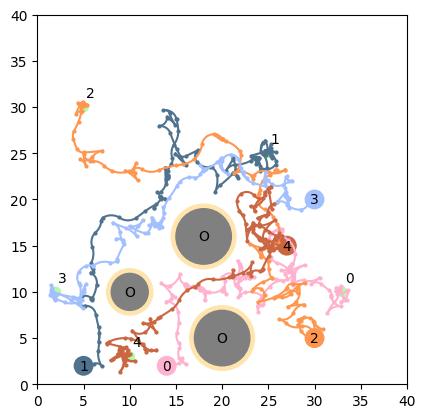

In [6]:
# get path info
path_rrt_nodes, states, controls, timesteps, costs = crrt.get_path()

# define a list of colors for trees and paths to use in drawing function
tcol =['y', 'c', 'b', 'g', 'b', 'b']
pcol = ['xkcd:powder pink', 'xkcd:metallic blue', 'xkcd:pastel orange', 'xkcd:pastel blue', 'xkcd:terracotta', 'xkcd:purplish grey']

mprint = MultiRRTPrinter(env, crrt, path_rrt_nodes, tcol, pcol, joint_states=True)
# setting print_tree to true will show the tree as well
mprint.print_rrt('../media/five_unicycle_crrt.png', print_tree=False)

### 3D STUFF

Kino-TI KCBS 

In [1]:
import sys
sys.path.append('../src')
import time
import numpy as np

from Environments import CuboidEnvironment, CuboidObstacle3D
from kcbs import *
from kinodynamic_TI_eb_rrt import * 
from edge_bundle import EdgeBundle
from kd_tree_quadcopter6d import *
from mapf_env_cuboid_agent_quadcopter6d import get_quadcopter_agent, \
    get_rrt_planner, get_kino_TI_eb_rrt_planner, get_kino_TI_eb_rrt_planner_grid

In [2]:
obstacles = [
  CuboidObstacle3D(x=5.288024544853885, y=10.428115301068528, z=4.381429795846468, l=1.3839478994290928, w=0.5401805203430455, h=8.762859591692935),
  CuboidObstacle3D(x=11.954231894339882, y=8.603275488906887, z=4.1909151213488585, l=0.4894908302066708, w=1.3916708816110792, h=8.381830242697717),
  CuboidObstacle3D(x=5.09798694910239, y=4.379210742901877, z=3.5329163210542545, l=1.012947629187785, w=0.8241902727000516, h=7.065832642108509),
  CuboidObstacle3D(x=1.2515176919283175, y=6.382882438156907, z=3.7064760014154894, l=0.8154560303422158, w=0.9315903102362977, h=7.412952002830979),
  CuboidObstacle3D(x=3.571110230587391, y=11.42056387486772, z=4.2468278944017905, l=1.3569195226036317, w=0.5305939467851933, h=8.493655788803581),
  CuboidObstacle3D(x=7.747853019130037, y=6.206600327515435, z=4.375561998755278, l=0.7725502893336461, w=1.0734098954898244, h=8.751123997510556),
  CuboidObstacle3D(x=9.369922496110094, y=3.789125351106821, z=3.866387903731101, l=1.41759692208027, w=0.494146098178711, h=7.732775807462202),
  CuboidObstacle3D(x=7.572100162570637, y=8.433738463586065, z=3.7151803959960374, l=0.6944531823772292, w=0.9656203291792224, h=7.430360791992075),
  CuboidObstacle3D(x=1.3788626583269576, y=4.612971585766165, z=3.602016866375745, l=0.6801371563340349, w=1.0735310416558315, h=7.20403373275149),
  CuboidObstacle3D(x=1.2517230753901782, y=8.230925811928927, z=3.8643541654261577, l=0.8436815330362557, w=0.6464442743787236, h=7.7287083308523155),
  CuboidObstacle3D(x=11.937082922873042, y=3.321434501007907, z=4.427651086838168, l=0.8820119319327673, w=1.0452295541498402, h=8.855302173676336),
  CuboidObstacle3D(x=2.6144639370162315, y=4.4039025815115345, z=3.2908979727461443, l=0.5014458528208032, w=1.3934776335531336, h=6.5817959454922885),
  CuboidObstacle3D(x=8.882920490259526, y=11.497996916324377, z=3.6938262682356733, l=0.4695094664176922, w=1.3328617718899038, h=7.387652536471347),
  CuboidObstacle3D(x=10.771924060959083, y=6.681457358183268, z=3.947871746185684, l=0.4353548933573186, w=1.1882000449382848, h=7.895743492371368),
  CuboidObstacle3D(x=5.156669442822354, y=9.227777527413963, z=4.005500757253257, l=0.9586972526631968, w=1.021113964861763, h=8.011001514506514),
  CuboidObstacle3D(x=3.654977319031023, y=2.4409283243404722, z=3.7095992809212595, l=0.5059145301349421, w=1.061011454249298, h=7.419198561842519),
]

env = CuboidEnvironment(length=14.0, breadth=14.0, height=10.0, obs=obstacles)

starts = [
    np.array((1.0, 1.0, 0.6, 0.0, 0.0, 0.0), dtype=np.float64),
    np.array((13.0, 1.0, 0.6, 0.0, 0.0, 0.0), dtype=np.float64),
    np.array((1.0, 13.0, 0.6, 0.0, 0.0, 0.0), dtype=np.float64),
    np.array((13.0, 13.0, 0.6, 0.0, 0.0, 0.0), dtype=np.float64),
    np.array((7.0, 1.0, 0.6, 0.0, 0.0, 0.0), dtype=np.float64),
    np.array((7.0, 3.0, 0.6, 0.0, 0.0, 0.0), dtype=np.float64),
]
goals = [
    np.array((13.0, 13.0, 8.6), dtype=np.float64),
    np.array((1.0, 13.0, 3.6), dtype=np.float64),
    np.array((13.0, 1.0, 7.6), dtype=np.float64),
    np.array((1.0, 1.0, 1.6), dtype=np.float64),
    np.array((7.0, 13.0, 5.6), dtype=np.float64),
    np.array((7.0, 7.0, 8.6), dtype=np.float64),
]

goal_radius = 0.3

num_agents = len(starts)
agent_ids = []
agents = []
for agent_id in range(num_agents):
    agent_ids.append(agent_id)
    agents.append(get_quadcopter_agent(agent_id))

seeds = [93, 228, 828, 760, 472, 701, 881, 140, 365, 160]


In [3]:
seed_index = 0
s = seeds[seed_index]
planners = []
# planner_function = get_rrt_planner
# planner_function = get_kino_TI_eb_rrt_planner
planner_function = get_kino_TI_eb_rrt_planner_grid
for i in range(num_agents):
    planners.append(planner_function(starts[i], goals[i], goal_radius,
                                        agents[i], env,
                                        edge_bundle_file_location='../edge_bundles/eb_quadcopter6d_kinodynamic_TI_edges_200000.npz'))

kcbs_planner = KCBS(
    env=env,
    agents=agents,
    low_level_planners=planners,
    max_trials=1000,
    planning_time=300.0,
    rng_seed=s,
    print_logs=False,
    debug_flag=False,
)
t = time.time()
path_found, paths, cost, delta_t = kcbs_planner.plan_multi_agent_paths()
t = time.time() - t
print(f"Iteration: {seed_index}")
print(f"RNG Seed: {s}")
print("Time taken for planning: {:.3f}s".format(t))
print(f"Cost: {cost}")

Iteration: 0
RNG Seed: 93
Time taken for planning: 6.234s
Cost: 202.19999999999996


Nodes gather skipped
Nodes gathered


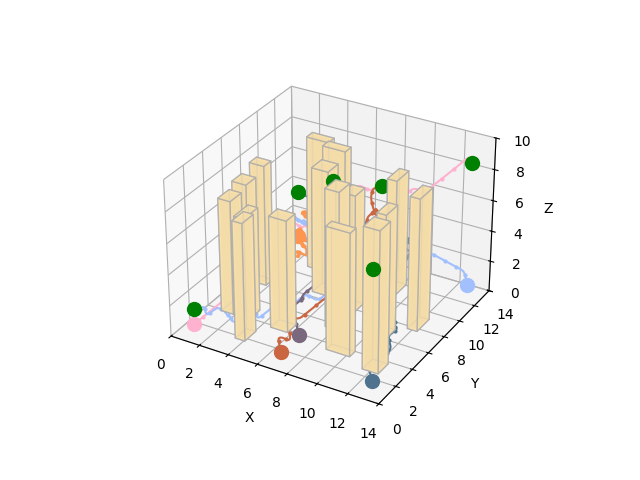

In [6]:
%matplotlib ipympl
from printer_3d import MultiRRTPrinter3d

planner_list = [planners[i] for i in range(num_agents)]

path_node = kcbs_planner.path_cbs_node
dict_paths = {}
ids_list = []
for i in range(num_agents):
    t = path_node.agent_trees[i]
    planners[i].tree = t[0]
    planners[i]._node_matrix = t[1]
    goal_id = next(reversed(t[0]._node))
    planners[i].goal_node_id = goal_id
    planners[i].path_found = True
    dict_paths[i] = planners[i].get_high_resolution_path()
    ids, states, controls, timesteps = planners[i].get_path()
    ids_list.append(ids)

# define a list of colors for trees and paths to use in drawing function
tcol =['y', 'c', 'b', 'g', 'b', 'b']
pcol = ['xkcd:powder pink', 'xkcd:metallic blue', 'xkcd:pastel orange', 'xkcd:pastel blue', 'xkcd:terracotta', 'xkcd:purplish grey']
mprint = MultiRRTPrinter3d(env, planner_list, ids_list, tcol, pcol)
mprint.print_rrt('../media/six_quad_kcbs_rrt_kino-ti-eb.png', print_tree=False)

Start Gathering: 
Gathering for agent: 0
Gathering for agent: 1
Gathering for agent: 2
Gathering for agent: 3
Gathering for agent: 4
Gathering for agent: 5
Done gathering, now animating
Done animating, now saving


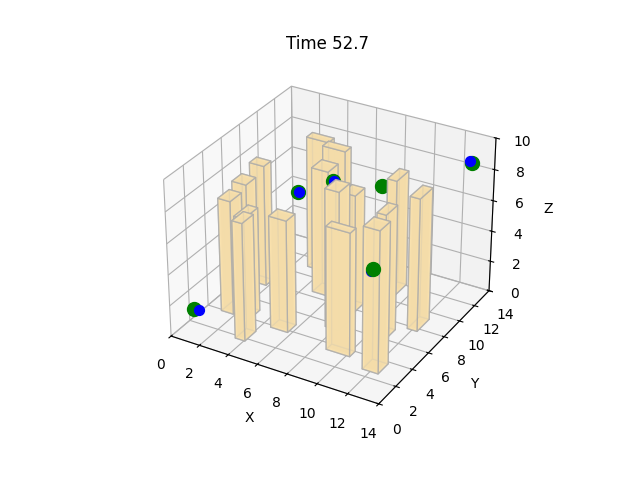

In [6]:
%matplotlib widget
# The speed param is the time between each 
# step in the gif (lower number->faster animation speed)
mprint.print_highres_simulation(dict_paths, "../media/six_quad_kcbs_rrt_kino-ti-eb_sim.gif", animation_speed=50)

PRRT

In [1]:
import sys
sys.path.append('../src')
import time
import numpy as np
import math

from Environments import CuboidEnvironment, CuboidObstacle3D
from prrt import PRRT
from mapf_env_cuboid_agent_quadcopter6d import get_quadcopter_agent, \
    get_rrt_planner, get_kino_TI_eb_rrt_planner, get_kino_TI_eb_rrt_planner_grid
from printer_3d import MultiRRTPrinter3d

In [2]:
obstacles = [
  CuboidObstacle3D(x=5.288024544853885, y=10.428115301068528, z=4.381429795846468, l=1.3839478994290928, w=0.5401805203430455, h=8.762859591692935),
  CuboidObstacle3D(x=11.954231894339882, y=8.603275488906887, z=4.1909151213488585, l=0.4894908302066708, w=1.3916708816110792, h=8.381830242697717),
  CuboidObstacle3D(x=5.09798694910239, y=4.379210742901877, z=3.5329163210542545, l=1.012947629187785, w=0.8241902727000516, h=7.065832642108509),
  CuboidObstacle3D(x=1.2515176919283175, y=6.382882438156907, z=3.7064760014154894, l=0.8154560303422158, w=0.9315903102362977, h=7.412952002830979),
  CuboidObstacle3D(x=3.571110230587391, y=11.42056387486772, z=4.2468278944017905, l=1.3569195226036317, w=0.5305939467851933, h=8.493655788803581),
  CuboidObstacle3D(x=7.747853019130037, y=6.206600327515435, z=4.375561998755278, l=0.7725502893336461, w=1.0734098954898244, h=8.751123997510556),
  CuboidObstacle3D(x=9.369922496110094, y=3.789125351106821, z=3.866387903731101, l=1.41759692208027, w=0.494146098178711, h=7.732775807462202),
  CuboidObstacle3D(x=7.572100162570637, y=8.433738463586065, z=3.7151803959960374, l=0.6944531823772292, w=0.9656203291792224, h=7.430360791992075),
  CuboidObstacle3D(x=1.3788626583269576, y=4.612971585766165, z=3.602016866375745, l=0.6801371563340349, w=1.0735310416558315, h=7.20403373275149),
  CuboidObstacle3D(x=1.2517230753901782, y=8.230925811928927, z=3.8643541654261577, l=0.8436815330362557, w=0.6464442743787236, h=7.7287083308523155),
  CuboidObstacle3D(x=11.937082922873042, y=3.321434501007907, z=4.427651086838168, l=0.8820119319327673, w=1.0452295541498402, h=8.855302173676336),
  CuboidObstacle3D(x=2.6144639370162315, y=4.4039025815115345, z=3.2908979727461443, l=0.5014458528208032, w=1.3934776335531336, h=6.5817959454922885),
  CuboidObstacle3D(x=8.882920490259526, y=11.497996916324377, z=3.6938262682356733, l=0.4695094664176922, w=1.3328617718899038, h=7.387652536471347),
  CuboidObstacle3D(x=10.771924060959083, y=6.681457358183268, z=3.947871746185684, l=0.4353548933573186, w=1.1882000449382848, h=7.895743492371368),
  CuboidObstacle3D(x=5.156669442822354, y=9.227777527413963, z=4.005500757253257, l=0.9586972526631968, w=1.021113964861763, h=8.011001514506514),
  CuboidObstacle3D(x=3.654977319031023, y=2.4409283243404722, z=3.7095992809212595, l=0.5059145301349421, w=1.061011454249298, h=7.419198561842519),
]

env = CuboidEnvironment(length=14.0, breadth=14.0, height=10.0, obs=obstacles)

starts = [
    np.array((1.0, 1.0, 0.6, 0.0, 0.0, 0.0), dtype=np.float64),
    np.array((13.0, 1.0, 0.6, 0.0, 0.0, 0.0), dtype=np.float64),
    np.array((1.0, 13.0, 0.6, 0.0, 0.0, 0.0), dtype=np.float64),
    np.array((13.0, 13.0, 0.6, 0.0, 0.0, 0.0), dtype=np.float64),
    np.array((7.0, 1.0, 0.6, 0.0, 0.0, 0.0), dtype=np.float64),
    np.array((7.0, 3.0, 0.6, 0.0, 0.0, 0.0), dtype=np.float64),
]
goals = [
    np.array((13.0, 13.0, 8.6), dtype=np.float64),
    np.array((1.0, 13.0, 3.6), dtype=np.float64),
    np.array((13.0, 1.0, 7.6), dtype=np.float64),
    np.array((1.0, 1.0, 1.6), dtype=np.float64),
    np.array((7.0, 13.0, 5.6), dtype=np.float64),
    np.array((7.0, 7.0, 8.6), dtype=np.float64),
]

num_agents = len(starts)

goal_radius = 0.3
goal_radii = [goal_radius for _ in range(num_agents)]

agent_ids = []
agents = []
for agent_id in range(num_agents):
    agent_ids.append(agent_id)
    agents.append(get_quadcopter_agent(agent_id))

seeds = [93, 228, 828, 760, 472, 701, 881, 140, 365, 160]

In [4]:
isvalid_fucs = [agent.is_new_node_valid for agent in agents]
cost_funcs = [agent.get_cost for agent in agents]
random_pt_funcs = [agent.get_random_point for agent in agents]
reached_goal_funcs = [agent.agent_reached_goal for agent in agents]

(paths, states, controls, timesteps, rrts, end_time) = PRRT.plan_multi(agents=agents, 
                                        starts=starts,
                                        goals=goals,
                                        goal_radii=goal_radii,
                                        env=env,
                                        max_iter = 300000, planning_time=math.inf,         
                                        isvalid_function=isvalid_fucs, 
                                        cost_function=cost_funcs,
                                        random_point_function=random_pt_funcs, 
                                        reached_goal_function = reached_goal_funcs,
                                        udf_seed = 158,
                                        print_logs=True
                                        )
end_time

New Agent at 1.9073486328125e-06 seconds.
Total Planning Time for agent 0 after 1192 iterations:  0.049990177154541016
New Agent at 0.0516362190246582 seconds.
Total Planning Time for agent 1 after 873 iterations:  0.03426218032836914
New Agent at 0.08739447593688965 seconds.
Total Planning Time for agent 2 after 633 iterations:  0.025057315826416016
New Agent at 0.11385130882263184 seconds.
Total Planning Time for agent 3 after 1023 iterations:  0.039306640625
New Agent at 0.15446805953979492 seconds.
Total Planning Time for agent 4 after 350 iterations:  0.013002157211303711
New Agent at 0.16837573051452637 seconds.
Total Planning Time for agent 5 after 1937 iterations:  0.07625555992126465


0.24569082260131836

Nodes gather skipped
Nodes gathered


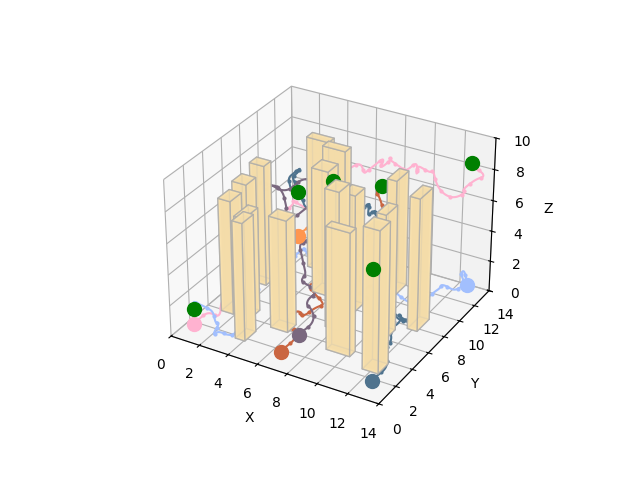

In [8]:
%matplotlib ipympl

# define a list of colors for trees and paths to use in drawing function
tcol =['y', 'c', 'b', 'g', 'b', 'b']
pcol = ['xkcd:powder pink', 'xkcd:metallic blue', 'xkcd:pastel orange', 'xkcd:pastel blue', 'xkcd:terracotta', 'xkcd:purplish grey']

mprint = MultiRRTPrinter3d(env, rrts, paths, tcol, pcol)
# setting print_tree to true will show the tree as well
mprint.print_rrt('../media/six_quad_prrt.png', print_tree=False)

Start Gathering: 
Gathering for agent: 0
Gathering for agent: 1
Gathering for agent: 2
Gathering for agent: 3
Gathering for agent: 4
Gathering for agent: 5
Done gathering, now animating
Done animating, now saving


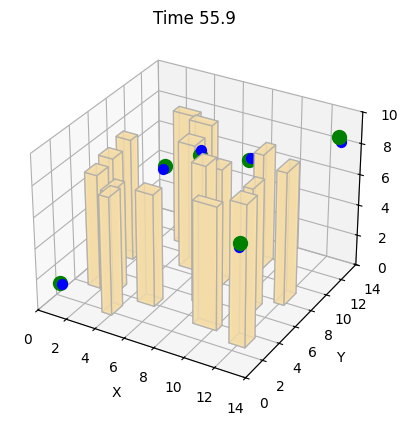

In [8]:
%matplotlib ipympl

# get high-res paths for each agent 
highres_paths = dict(enumerate([planner.get_high_resolution_path() for planner in rrts]))
# The speed param is the time between each 
# step in the gif (lower number->faster animation speed)
mprint.print_highres_simulation(highres_paths, '../media/six_quad_prrt_sim.gif', animation_speed=100)

Prioritized Planning with KITE

In [2]:
import sys
sys.path.append('../src')
import time
import numpy as np
import math

from Environments import CuboidEnvironment, CuboidObstacle3D
from prioritized_planning import PrioritizedPlaning
from kinodynamic_TI_eb_rrt import * 
from mapf_env_cuboid_agent_quadcopter6d import get_quadcopter_agent, \
    get_rrt_planner, get_kino_TI_eb_rrt_planner, get_kino_TI_eb_rrt_planner_grid
from printer_3d import MultiRRTPrinter3d

In [31]:
obstacles = [
  CuboidObstacle3D(x=5.288024544853885, y=10.428115301068528, z=4.381429795846468, l=1.3839478994290928, w=0.5401805203430455, h=8.762859591692935),
  CuboidObstacle3D(x=11.954231894339882, y=8.603275488906887, z=4.1909151213488585, l=0.4894908302066708, w=1.3916708816110792, h=8.381830242697717),
  CuboidObstacle3D(x=5.09798694910239, y=4.379210742901877, z=3.5329163210542545, l=1.012947629187785, w=0.8241902727000516, h=7.065832642108509),
  CuboidObstacle3D(x=1.2515176919283175, y=6.382882438156907, z=3.7064760014154894, l=0.8154560303422158, w=0.9315903102362977, h=7.412952002830979),
  CuboidObstacle3D(x=3.571110230587391, y=11.42056387486772, z=4.2468278944017905, l=1.3569195226036317, w=0.5305939467851933, h=8.493655788803581),
  CuboidObstacle3D(x=7.747853019130037, y=6.206600327515435, z=4.375561998755278, l=0.7725502893336461, w=1.0734098954898244, h=8.751123997510556),
  CuboidObstacle3D(x=9.369922496110094, y=3.789125351106821, z=3.866387903731101, l=1.41759692208027, w=0.494146098178711, h=7.732775807462202),
  CuboidObstacle3D(x=7.572100162570637, y=8.433738463586065, z=3.7151803959960374, l=0.6944531823772292, w=0.9656203291792224, h=7.430360791992075),
  CuboidObstacle3D(x=1.3788626583269576, y=4.612971585766165, z=3.602016866375745, l=0.6801371563340349, w=1.0735310416558315, h=7.20403373275149),
  CuboidObstacle3D(x=1.2517230753901782, y=8.230925811928927, z=3.8643541654261577, l=0.8436815330362557, w=0.6464442743787236, h=7.7287083308523155),
  CuboidObstacle3D(x=11.937082922873042, y=3.321434501007907, z=4.427651086838168, l=0.8820119319327673, w=1.0452295541498402, h=8.855302173676336),
  CuboidObstacle3D(x=2.6144639370162315, y=4.4039025815115345, z=3.2908979727461443, l=0.5014458528208032, w=1.3934776335531336, h=6.5817959454922885),
  CuboidObstacle3D(x=8.882920490259526, y=11.497996916324377, z=3.6938262682356733, l=0.4695094664176922, w=1.3328617718899038, h=7.387652536471347),
  CuboidObstacle3D(x=10.771924060959083, y=6.681457358183268, z=3.947871746185684, l=0.4353548933573186, w=1.1882000449382848, h=7.895743492371368),
  CuboidObstacle3D(x=5.156669442822354, y=9.227777527413963, z=4.005500757253257, l=0.9586972526631968, w=1.021113964861763, h=8.011001514506514),
  CuboidObstacle3D(x=3.654977319031023, y=2.4409283243404722, z=3.7095992809212595, l=0.5059145301349421, w=1.061011454249298, h=7.419198561842519),
]

env = CuboidEnvironment(length=14.0, breadth=14.0, height=10.0, obs=obstacles)

starts = [
            (1.0, 1.0, 0.6, 0.0, 0.0, 0.0), 
            (13.0, 1.0, 0.6, 0.0, 0.0, 0.0), 
            (1.0, 13.0, 0.6, 0.0, 0.0, 0.0), 
            (13.0, 13.0, 0.6, 0.0, 0.0, 0.0), 
            (7.0, 1.0, 0.6, 0.0, 0.0, 0.0), 
            (7.0, 3.0, 0.6, 0.0, 0.0, 0.0),
            (2.5, 6.5, 0.5, 0.0, 0.0, 0.0),
            (11.5, 10.5, 1.0, 0.0, 0.0, 0.0),
            (5.0, 2.0, 0.6, 0.0, 0.0, 0.0),
            (10.0, 5.0, 1.5, 0.0, 0.0, 0.0),
            (7.0, 10.0, 0.8, 0.0, 0.0, 0.0),
            (2.0, 10.0, 1.0, 0.0, 0.0, 0.0),
            (12.0, 5.0, 2.0, 0.0, 0.0, 0.0),
            (9.0, 1.5, 0.7, 0.0, 0.0, 0.0),
            (3.5, 9.0, 1.2, 0.0, 0.0, 0.0),
            (10.5, 12.0, 1.5, 0.0, 0.0, 0.0),
            (5.5, 5.5, 0.9, 0.0, 0.0, 0.0),
            (12.5, 7.2, 2.5, 0.0, 0.0, 0.0),
            (2.0, 3.0, 1.5, 0.0, 0.0, 0.0),
            (8.5, 10.0, 2.0, 0.0, 0.0, 0.0),
            (4.5, 7.0, 1.0, 0.0, 0.0, 0.0),
            (7.5, 12.0, 2.5, 0.0, 0.0, 0.0),
            (11.0, 9.0, 0.6, 0.0, 0.0, 0.0),
            (1.5, 3.0, 5.0, 0.0, 0.0, 0.0),
            (9.5, 2.5, 1.8, 0.0, 0.0, 0.0),
            (6.5, 2.0, 0.7, 0.0, 0.0, 0.0),
            (3.0, 13.0, 1.5, 0.0, 0.0, 0.0),
            (10.5, 8.5, 1.2, 0.0, 0.0, 0.0),
            (5.5, 11.5, 2.0, 0.0, 0.0, 0.0),
            (9.0, 6.0, 0.8, 0.0, 0.0, 0.0),
        ]

goals = [
            (13.0, 13.0, 8.6), 
            (1.0, 13.0, 3.6), 
            (13.0, 1.0, 7.6), 
            (1.0, 1.0, 1.6), 
            (7.0, 13.0, 5.6), 
            (7.0, 7.0, 8.6),
            (11.0, 2.0, 2.5),
            (2.5, 3.5, 0.8),
            (12.5, 11.5, 8.0),
            (1.5, 7.5, 4.0),
            (2.0, 1.5, 3.0),
            (10.0, 1.0, 5.5),
            (1.5, 12.0, 7.0),
            (12.0, 6.5, 3.5),
            (8.5, 1.5, 6.5),
            (3.0, 12.5, 2.5),
            (13.0, 8.0, 4.0),
            (4.5, 1.5, 7.0),
            (12.0, 12.5, 5.0),
            (5.0, 0.8, 8.5),
            (6.5, 12.0, 3.5),
            (12.5, 4.5, 1.5),
            (2.8, 2.5, 7.5),
            (10.0, 11.0, 2.0),
            (1.0, 9.5, 6.0),
            (13.0, 5.0, 8.5),
            (3.0, 10.0, 1.5),
            (11.5, 1.8, 4.0),
            (7.5, 3.5, 9.0),
            (2.5, 8.0, 2.5),
]
goal_radius = 0.3

num_agents = len(starts)
agent_ids = []
agents = []
for agent_id in range(num_agents):
    agent_ids.append(agent_id)
    agents.append(get_quadcopter_agent(agent_id))

seeds = [93, 228, 828, 760, 472, 701, 881, 140, 365, 160]


In [32]:
seed_index = 0
s = seeds[seed_index]
planners = []
# planner_function = get_rrt_planner
# planner_function = get_kino_TI_eb_rrt_planner
planner_function = get_kino_TI_eb_rrt_planner_grid
for i in range(num_agents):
    planners.append(planner_function(starts[i], goals[i], goal_radius,
                                        agents[i], env,
                                        edge_bundle_file_location='../edge_bundles/eb_quadcopter6d_kinodynamic_TI_edges_200000.npz'))

PrioritizedPlaning.plan_multi(planners=planners, planning_time=100, print_logs=True)

Planning for agent 0 with id 0
Total Planning Time for agent 0 after 253 iterations:  0.024068593978881836
Planning for agent 1 with id 1
Total Planning Time for agent 1 after 922 iterations:  0.06677985191345215
Planning for agent 2 with id 2
Total Planning Time for agent 2 after 264 iterations:  0.026587486267089844
Planning for agent 3 with id 3
Total Planning Time for agent 3 after 170 iterations:  0.015272855758666992
Planning for agent 4 with id 4
Total Planning Time for agent 4 after 289 iterations:  0.030589580535888672
Planning for agent 5 with id 5
Total Planning Time for agent 5 after 742 iterations:  0.09065842628479004
Planning for agent 6 with id 6
Total Planning Time for agent 6 after 120 iterations:  0.012652873992919922
Planning for agent 7 with id 7
Total Planning Time for agent 7 after 140446 iterations:  21.130207300186157
Planning for agent 8 with id 8
Total Planning Time for agent 8 after 251 iterations:  0.0257415771484375
Planning for agent 9 with id 9
Total Pla

(True, 22.17940616607666, 802.0999999999998)

Nodes gather skipped
Nodes gathered


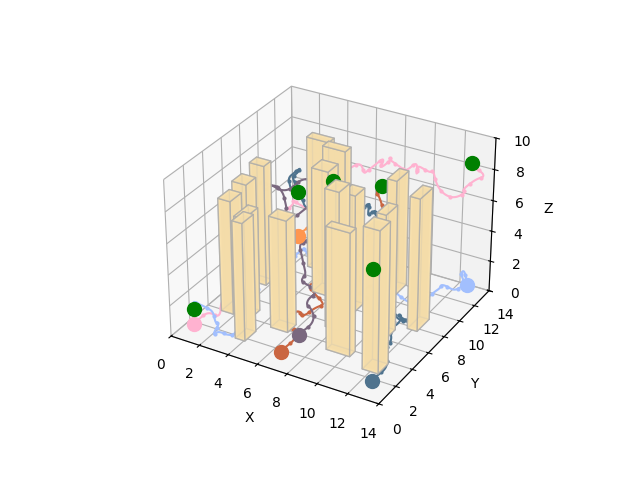

In [ ]:
%matplotlib ipympl

# define a list of colors for trees and paths to use in drawing function
tcol =['y', 'c', 'b', 'g', 'b', 'b']
pcol = ['xkcd:powder pink', 'xkcd:metallic blue', 'xkcd:pastel orange', 'xkcd:pastel blue', 'xkcd:terracotta', 'xkcd:purplish grey']

mprint = MultiRRTPrinter3d(env, rrts, paths, tcol, pcol)
# setting print_tree to true will show the tree as well
mprint.print_rrt('../media/six_quad_priority_kite.png', print_tree=False)

Start Gathering: 
Gathering for agent: 0
Gathering for agent: 1
Gathering for agent: 2
Gathering for agent: 3
Gathering for agent: 4
Gathering for agent: 5
Done gathering, now animating
Done animating, now saving


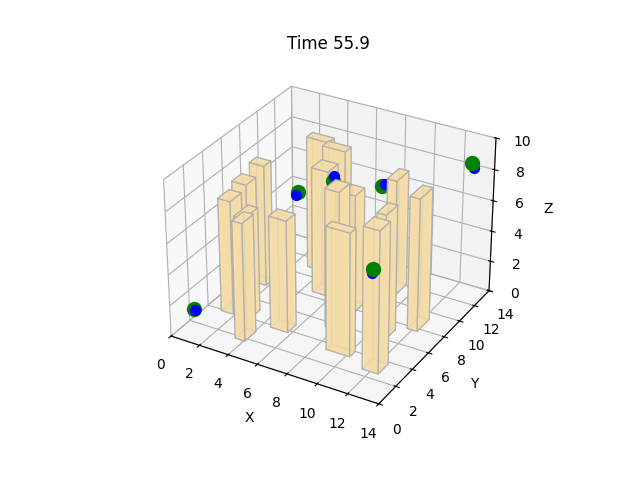

In [14]:
%matplotlib ipympl

# get high-res paths for each agent 
highres_paths = dict(enumerate([planner.get_high_resolution_path() for planner in rrts]))
# The speed param is the time between each 
# step in the gif (lower number->faster animation speed)
mprint.print_highres_simulation(highres_paths, '../media/six_quad_priority_kite_sim.gif', animation_speed=100)

CRRT

In [1]:
import sys
sys.path.append('../src')

import math

from Environments import *
from cRRT import CRRT
from Environments import CuboidEnvironment, CuboidObstacle3D
from mapf_env_cuboid_agent_quadcopter6d import get_quadcopter_agent, \
    get_rrt_planner, get_kino_TI_eb_rrt_planner, get_kino_TI_eb_rrt_planner_grid
from printer_3d import MultiRRTPrinter3d

In [18]:
obstacles = [
  CuboidObstacle3D(x=5.288024544853885, y=10.428115301068528, z=4.381429795846468, l=1.3839478994290928, w=0.5401805203430455, h=8.762859591692935),
  CuboidObstacle3D(x=11.954231894339882, y=8.603275488906887, z=4.1909151213488585, l=0.4894908302066708, w=1.3916708816110792, h=8.381830242697717),
  CuboidObstacle3D(x=5.09798694910239, y=4.379210742901877, z=3.5329163210542545, l=1.012947629187785, w=0.8241902727000516, h=7.065832642108509),
  CuboidObstacle3D(x=1.2515176919283175, y=6.382882438156907, z=3.7064760014154894, l=0.8154560303422158, w=0.9315903102362977, h=7.412952002830979),
  CuboidObstacle3D(x=3.571110230587391, y=11.42056387486772, z=4.2468278944017905, l=1.3569195226036317, w=0.5305939467851933, h=8.493655788803581),
  CuboidObstacle3D(x=7.747853019130037, y=6.206600327515435, z=4.375561998755278, l=0.7725502893336461, w=1.0734098954898244, h=8.751123997510556),
  CuboidObstacle3D(x=9.369922496110094, y=3.789125351106821, z=3.866387903731101, l=1.41759692208027, w=0.494146098178711, h=7.732775807462202),
  CuboidObstacle3D(x=7.572100162570637, y=8.433738463586065, z=3.7151803959960374, l=0.6944531823772292, w=0.9656203291792224, h=7.430360791992075),
  CuboidObstacle3D(x=1.3788626583269576, y=4.612971585766165, z=3.602016866375745, l=0.6801371563340349, w=1.0735310416558315, h=7.20403373275149),
  CuboidObstacle3D(x=1.2517230753901782, y=8.230925811928927, z=3.8643541654261577, l=0.8436815330362557, w=0.6464442743787236, h=7.7287083308523155),
  CuboidObstacle3D(x=11.937082922873042, y=3.321434501007907, z=4.427651086838168, l=0.8820119319327673, w=1.0452295541498402, h=8.855302173676336),
  CuboidObstacle3D(x=2.6144639370162315, y=4.4039025815115345, z=3.2908979727461443, l=0.5014458528208032, w=1.3934776335531336, h=6.5817959454922885),
  CuboidObstacle3D(x=8.882920490259526, y=11.497996916324377, z=3.6938262682356733, l=0.4695094664176922, w=1.3328617718899038, h=7.387652536471347),
  CuboidObstacle3D(x=10.771924060959083, y=6.681457358183268, z=3.947871746185684, l=0.4353548933573186, w=1.1882000449382848, h=7.895743492371368),
  CuboidObstacle3D(x=5.156669442822354, y=9.227777527413963, z=4.005500757253257, l=0.9586972526631968, w=1.021113964861763, h=8.011001514506514),
  CuboidObstacle3D(x=3.654977319031023, y=2.4409283243404722, z=3.7095992809212595, l=0.5059145301349421, w=1.061011454249298, h=7.419198561842519),
]

env = CuboidEnvironment(length=14.0, breadth=14.0, height=10.0, obs=obstacles)

starts = [
    np.array((1.0, 1.0, 0.6, 0.0, 0.0, 0.0), dtype=np.float64),
    np.array((13.0, 1.0, 0.6, 0.0, 0.0, 0.0), dtype=np.float64),
    np.array((1.0, 13.0, 0.6, 0.0, 0.0, 0.0), dtype=np.float64),
    np.array((13.0, 13.0, 0.6, 0.0, 0.0, 0.0), dtype=np.float64),
    np.array((7.0, 1.0, 0.6, 0.0, 0.0, 0.0), dtype=np.float64),
    # np.array((7.0, 3.0, 0.6, 0.0, 0.0, 0.0), dtype=np.float64),
]
goals = [
    np.array((13.0, 13.0, 8.6), dtype=np.float64),
    np.array((1.0, 13.0, 3.6), dtype=np.float64),
    np.array((13.0, 1.0, 7.6), dtype=np.float64),
    np.array((1.0, 1.0, 1.6), dtype=np.float64),
    np.array((7.0, 13.0, 5.6), dtype=np.float64),
    np.array((7.0, 7.0, 8.6), dtype=np.float64),
]

goal_radius = 0.3

goal_radii = [0.5 for _ in goals]

num_agents = len(starts)
agent_ids = []
agents = []
for agent_id in range(num_agents):
    agent_ids.append(agent_id)
    agents.append(get_quadcopter_agent(agent_id))

seeds = [93, 228, 828, 760, 472, 701, 881, 140, 365, 160]


In [19]:
isvalid_funcs = [agent.is_new_node_valid for agent in agents]
cost_funcs = [agent.get_cost for agent in agents]
random_pt_funcs = [agent.get_random_point for agent in agents]
reached_goal_funcs = [agent.agent_reached_goal for agent in agents]

# instantiate CRRT obj
crrt = CRRT(agents=agents, 
            starts=starts,
            goals=goals,
            goal_radii=goal_radii,
            env=env,
            max_iter = math.inf, planning_time=math.inf,         
            isvalid_function=isvalid_funcs, 
            cost_function=cost_funcs,
            random_point_function=random_pt_funcs, 
            reached_goal_function = reached_goal_funcs,
            udf_seed = 321, 
            print_logs=True,
            truncate_paths=True,
            use_fixed_sampling_time=False
            
            )
# plan path 
planning_time = crrt.plan_path()

Total Planning Time after 74695 steps: 14.62452244758606


Nodes gather skipped
Nodes gathered


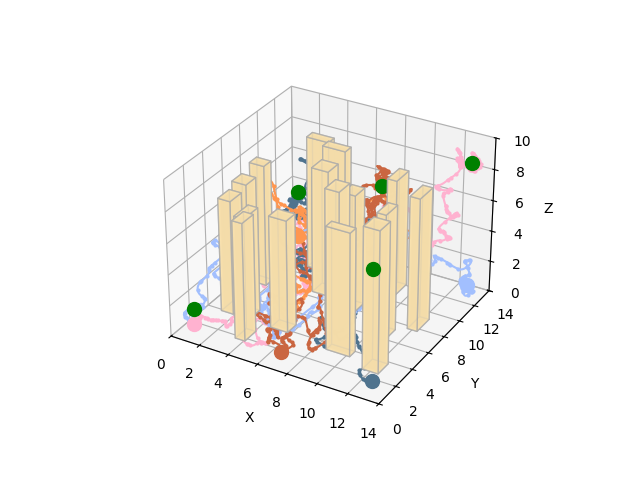

In [19]:
%matplotlib ipympl
# get path info
path_rrt_nodes, states, controls, timesteps, costs = crrt.get_path()

# define a list of colors for trees and paths to use in drawing function
tcol =['y', 'c', 'b', 'g', 'b', 'b']
pcol = ['xkcd:powder pink', 'xkcd:metallic blue', 'xkcd:pastel orange', 'xkcd:pastel blue', 'xkcd:terracotta', 'xkcd:purplish grey']

mprint = MultiRRTPrinter3d(env, crrt, path_rrt_nodes, tcol, pcol, joint_states=True)
# setting print_tree to true will show the tree as well
mprint.print_rrt('../media/five_quad_crrt.png', print_tree=False)

Start Gathering: 
Gathering for agent: 0
Gathering for agent: 1
Gathering for agent: 2
Gathering for agent: 3
Gathering for agent: 4
Done gathering, now animating
Done animating, now saving


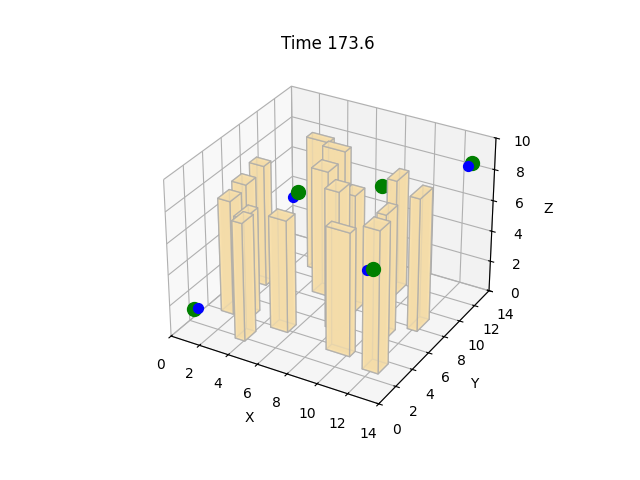

In [21]:
# get high-res paths for each agent 
highres_paths = dict(enumerate(crrt.get_high_resolution_paths()))
# The speed param is the time between each 
# step in the gif (lower number->faster animation speed)
mprint.print_highres_simulation(highres_paths, '../media/five_quad_crrt_sim.gif', animation_speed=100)

cKITE

In [1]:
import sys
sys.path.append('../src')

import math

from Environments import *
from kinodynamic_TI_eb_crrt import * 
from Environments import CuboidEnvironment, CuboidObstacle3D
from mapf_env_cuboid_agent_quadcopter6d import get_quadcopter_agent, \
    get_rrt_planner, get_kino_TI_eb_rrt_planner, get_kino_TI_eb_rrt_planner_grid, \
    get_kino_TI_eb
from printer_3d import MultiRRTPrinter3d

In [4]:
obstacles = [
  CuboidObstacle3D(x=5.288024544853885, y=10.428115301068528, z=4.381429795846468, l=1.3839478994290928, w=0.5401805203430455, h=8.762859591692935),
  CuboidObstacle3D(x=11.954231894339882, y=8.603275488906887, z=4.1909151213488585, l=0.4894908302066708, w=1.3916708816110792, h=8.381830242697717),
  CuboidObstacle3D(x=5.09798694910239, y=4.379210742901877, z=3.5329163210542545, l=1.012947629187785, w=0.8241902727000516, h=7.065832642108509),
  CuboidObstacle3D(x=1.2515176919283175, y=6.382882438156907, z=3.7064760014154894, l=0.8154560303422158, w=0.9315903102362977, h=7.412952002830979),
  CuboidObstacle3D(x=3.571110230587391, y=11.42056387486772, z=4.2468278944017905, l=1.3569195226036317, w=0.5305939467851933, h=8.493655788803581),
  CuboidObstacle3D(x=7.747853019130037, y=6.206600327515435, z=4.375561998755278, l=0.7725502893336461, w=1.0734098954898244, h=8.751123997510556),
  CuboidObstacle3D(x=9.369922496110094, y=3.789125351106821, z=3.866387903731101, l=1.41759692208027, w=0.494146098178711, h=7.732775807462202),
  CuboidObstacle3D(x=7.572100162570637, y=8.433738463586065, z=3.7151803959960374, l=0.6944531823772292, w=0.9656203291792224, h=7.430360791992075),
  CuboidObstacle3D(x=1.3788626583269576, y=4.612971585766165, z=3.602016866375745, l=0.6801371563340349, w=1.0735310416558315, h=7.20403373275149),
  CuboidObstacle3D(x=1.2517230753901782, y=8.230925811928927, z=3.8643541654261577, l=0.8436815330362557, w=0.6464442743787236, h=7.7287083308523155),
  CuboidObstacle3D(x=11.937082922873042, y=3.321434501007907, z=4.427651086838168, l=0.8820119319327673, w=1.0452295541498402, h=8.855302173676336),
  CuboidObstacle3D(x=2.6144639370162315, y=4.4039025815115345, z=3.2908979727461443, l=0.5014458528208032, w=1.3934776335531336, h=6.5817959454922885),
  CuboidObstacle3D(x=8.882920490259526, y=11.497996916324377, z=3.6938262682356733, l=0.4695094664176922, w=1.3328617718899038, h=7.387652536471347),
  CuboidObstacle3D(x=10.771924060959083, y=6.681457358183268, z=3.947871746185684, l=0.4353548933573186, w=1.1882000449382848, h=7.895743492371368),
  CuboidObstacle3D(x=5.156669442822354, y=9.227777527413963, z=4.005500757253257, l=0.9586972526631968, w=1.021113964861763, h=8.011001514506514),
  CuboidObstacle3D(x=3.654977319031023, y=2.4409283243404722, z=3.7095992809212595, l=0.5059145301349421, w=1.061011454249298, h=7.419198561842519),
]

env = CuboidEnvironment(length=14.0, breadth=14.0, height=10.0, obs=obstacles)

starts = [
    np.array((1.0, 1.0, 0.6, 0.0, 0.0, 0.0), dtype=np.float64),
    np.array((13.0, 1.0, 0.6, 0.0, 0.0, 0.0), dtype=np.float64),
    np.array((1.0, 13.0, 0.6, 0.0, 0.0, 0.0), dtype=np.float64),
    np.array((13.0, 13.0, 0.6, 0.0, 0.0, 0.0), dtype=np.float64),
    np.array((7.0, 1.0, 0.6, 0.0, 0.0, 0.0), dtype=np.float64),
    np.array((7.0, 3.0, 0.6, 0.0, 0.0, 0.0), dtype=np.float64),
]
goals = [
    np.array((13.0, 13.0, 8.6), dtype=np.float64),
    np.array((1.0, 13.0, 3.6), dtype=np.float64),
    np.array((13.0, 1.0, 7.6), dtype=np.float64),
    np.array((1.0, 1.0, 1.6), dtype=np.float64),
    np.array((7.0, 13.0, 5.6), dtype=np.float64),
    np.array((7.0, 7.0, 8.6), dtype=np.float64),
]

goal_radius = 0.3

goal_radii = [0.5 for _ in goals]

num_agents = len(starts)
agent_ids = []
agents = []
for agent_id in range(num_agents):
    agent_ids.append(agent_id)
    agents.append(get_quadcopter_agent(agent_id))

seeds = [93, 228, 828, 760, 472, 701, 881, 140, 365, 160]

In [5]:
isvalid_funcs = []
cost_funcs = []
random_pt_funcs = []
reached_goal_funcs = []
translate_funcs = []
sort_edges_functions = []
edge_bundles = []
eb_kd_trees = []
get_eb_kd_tree_query_funcs = []

for agent in agents:
    isvalid_funcs.append(agent.is_new_node_valid)
    cost_funcs.append(agent.get_cost)
    random_pt_funcs.append(agent.get_random_point)
    reached_goal_funcs.append(agent.agent_reached_goal)
    translate_funcs.append(agent.kd_tree_point_translate_function)
    sort_edges_functions.append(agent.sort_kd_tree_edges)
    kino_TI_eb_unicycle, kd_tree_TI_eb_unicycle = get_kino_TI_eb(agent, 
                                                                 edge_bundle_file_location='../edge_bundles/eb_quadcopter6d_kinodynamic_TI_edges_200000.npz')
    edge_bundles.append(kino_TI_eb_unicycle)
    eb_kd_trees.append(kd_tree_TI_eb_unicycle)
    get_eb_kd_tree_query_funcs.append(agent.get_eb_kd_tree_query)

# instantiate CRRT obj
crrt = KinoTIEBCRRT(agents=agents, 
            starts=starts,
            goals=goals,
            goal_radii=goal_radii,
            edge_bundle=edge_bundles,
            env=env,
            max_iter = math.inf, planning_time=math.inf,         
            isvalid_function=isvalid_funcs, 
            cost_function=cost_funcs,
            random_point_function=random_pt_funcs, 
            reached_goal_function = reached_goal_funcs,
            translate_function=translate_funcs,
            sort_edges_function=sort_edges_functions,
            udf_seed = 61, 
            print_logs=True,
            eb_kd_trees=eb_kd_trees,
            get_eb_kd_tree_query_funcs=get_eb_kd_tree_query_funcs,
            max_num_edges_per_node=1000,
            num_skip_edges= 100,
            num_random_edges= 10,
            kd_tree_delta_radius=0.5,
            truncate_paths=True,
            use_fixed_sampling_time=False
            )
# plan path 
planning_time = crrt.plan_path()
planning_time

Agents found goal [5] out of those that have {0: False, 1: False, 2: False, 3: False, 4: False, 5: False}
Agents found goal [5] out of those that have {0: False, 1: False, 2: False, 3: False, 4: False, 5: True}
Agents found goal [5] out of those that have {0: False, 1: False, 2: False, 3: False, 4: False, 5: True}
Agents found goal [5] out of those that have {0: False, 1: False, 2: False, 3: False, 4: False, 5: True}
Agents found goal [5] out of those that have {0: False, 1: False, 2: False, 3: False, 4: False, 5: True}
Agents found goal [5] out of those that have {0: False, 1: False, 2: False, 3: False, 4: False, 5: True}
Agents found goal [5] out of those that have {0: False, 1: False, 2: False, 3: False, 4: False, 5: True}
Agents found goal [5] out of those that have {0: False, 1: False, 2: False, 3: False, 4: False, 5: True}
Agents found goal [5] out of those that have {0: False, 1: False, 2: False, 3: False, 4: False, 5: True}
Agents found goal [5] out of those that have {0: False

5.858627557754517

Nodes gather skipped
Nodes gathered


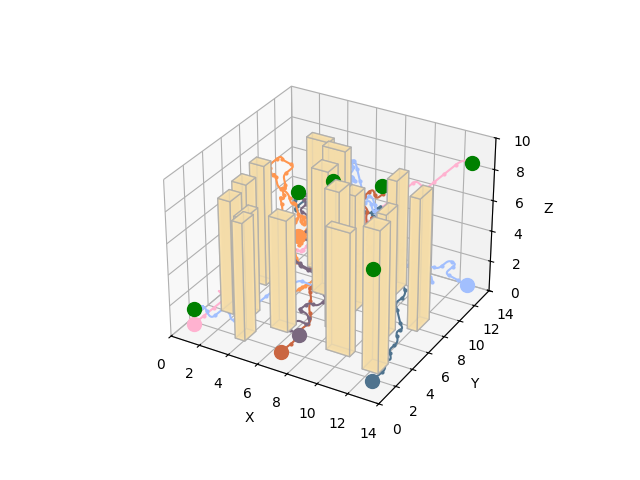

In [5]:
%matplotlib ipympl
# get path info
path_rrt_nodes, states, controls, timesteps, costs = crrt.get_path()

# define a list of colors for trees and paths to use in drawing function
tcol =['y', 'c', 'b', 'g', 'b', 'b']
pcol = ['xkcd:powder pink', 'xkcd:metallic blue', 'xkcd:pastel orange', 'xkcd:pastel blue', 'xkcd:terracotta', 'xkcd:purplish grey']

mprint = MultiRRTPrinter3d(env, crrt, path_rrt_nodes, tcol, pcol, joint_states=True)
# setting print_tree to true will show the tree as well
mprint.print_rrt('../media/five_quad_cKITE.png', print_tree=False)

Making more starts/goals:

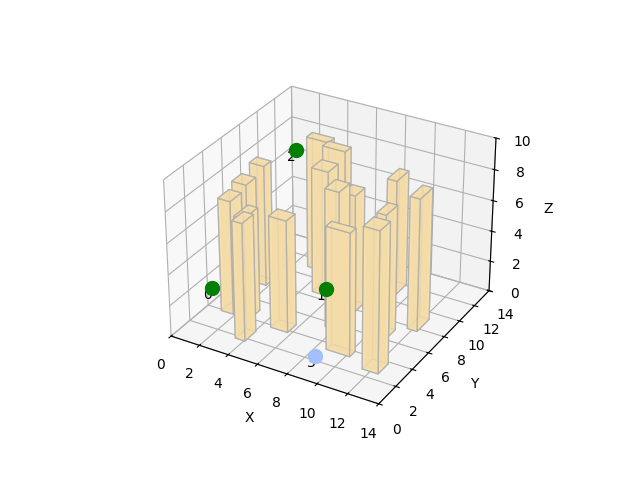

In [6]:
%matplotlib ipympl
import sys
sys.path.append('../src')
from printer_3d import MultiRRTPrinter3d
from Environments import CuboidEnvironment, CuboidObstacle3D
from mapf_env_cuboid_agent_quadcopter6d import get_quadcopter_agent

starts = [
            # (1.0, 1.0, 0.6, 0.0, 0.0, 0.0), 
            # (13.0, 1.0, 0.6, 0.0, 0.0, 0.0), 
            # (1.0, 13.0, 0.6, 0.0, 0.0, 0.0), 
            # (13.0, 13.0, 0.6, 0.0, 0.0, 0.0), 
            # (7.0, 1.0, 0.6, 0.0, 0.0, 0.0), 
            # (7.0, 3.0, 0.6, 0.0, 0.0, 0.0),
            # (2.5, 6.5, 0.5, 0.0, 0.0, 0.0),
            # (11.5, 10.5, 1.0, 0.0, 0.0, 0.0),
            # (5.0, 2.0, 0.6, 0.0, 0.0, 0.0),
            # (10.0, 5.0, 1.5, 0.0, 0.0, 0.0),
            (6.0, 10.0, 0.8, 0.0, 0.0, 0.0),
            (2.0, 10.0, 1.0, 0.0, 0.0, 0.0),
            (12.0, 4.0, 2.0, 0.0, 0.0, 0.0),
            (9.0, 1.5, 0.7, 0.0, 0.0, 0.0),
            # (3.5, 9.0, 1.2, 0.0, 0.0, 0.0),
            # (10.5, 12.0, 1.5, 0.0, 0.0, 0.0),
            # (5.5, 5.5, 0.9, 0.0, 0.0, 0.0),
            # (12.5, 7.5, 2.5, 0.0, 0.0, 0.0),
            # (2.0, 3.0, 1.5, 0.0, 0.0, 0.0),
            # (8.5, 10.0, 2.0, 0.0, 0.0, 0.0),
            # (4.5, 7.0, 1.0, 0.0, 0.0, 0.0),
            # (7.5, 12.0, 2.5, 0.0, 0.0, 0.0),
            # (11.0, 9.0, 0.6, 0.0, 0.0, 0.0),
            # (1.5, 4.5, 2.0, 0.0, 0.0, 0.0),
            # (9.5, 3.5, 1.8, 0.0, 0.0, 0.0),
            # (6.5, 2.0, 0.7, 0.0, 0.0, 0.0),
            # (3.0, 11.5, 1.5, 0.0, 0.0, 0.0),
            # (10.5, 8.5, 1.2, 0.0, 0.0, 0.0),
            # (5.5, 10.5, 2.0, 0.0, 0.0, 0.0),
            # (8.0, 6.0, 0.8, 0.0, 0.0, 0.0),
        ]

goals = [
            # (13.0, 13.0, 8.6), 
            # (1.0, 13.0, 3.6), 
            # (13.0, 1.0, 7.6), 
            # (1.0, 1.0, 1.6), 
            # (7.0, 13.0, 5.6), 
            # (7.0, 7.0, 8.6),
            # (11.0, 2.0, 2.5),
            # (2.5, 3.5, 0.8),
            # (12.5, 11.5, 8.0),
            # (1.5, 7.5, 4.0),
            (2.0, 1.5, 3.0),
            (10.0, 1.0, 5.5),
            (1.5, 12.0, 7.0),
            (11.0, 6.5, 3.5),
            # (8.5, 1.5, 6.5),
            # (3.0, 12.5, 2.5),
            # (13.0, 8.0, 4.0),
            # (4.5, 1.5, 7.0),
            # (12.0, 12.5, 5.0),
            # (5.0, 0.8, 8.5),
            # (6.5, 12.0, 3.5),
            # (12.5, 4.5, 1.5),
            # (3.5, 2.5, 7.5),
            # (9.0, 11.0, 2.0),
            # (1.0, 8.5, 6.0),
            # (13.0, 5.0, 8.5),
            # (4.5, 10.0, 1.5),
            # (11.5, 2.5, 4.0),
            # (7.5, 3.5, 9.0),
            # (2.5, 8.0, 2.5),
]

goal_radii = [0.5 for _ in goals]

obstacles = [
            CuboidObstacle3D(x=5.288024544853885, y=10.428115301068528, z=4.381429795846468, l=1.3839478994290928, w=0.5401805203430455, h=8.762859591692935),
            CuboidObstacle3D(x=11.954231894339882, y=8.603275488906887, z=4.1909151213488585, l=0.4894908302066708, w=1.3916708816110792, h=8.381830242697717),
            CuboidObstacle3D(x=5.09798694910239, y=4.379210742901877, z=3.5329163210542545, l=1.012947629187785, w=0.8241902727000516, h=7.065832642108509),
            CuboidObstacle3D(x=1.2515176919283175, y=6.382882438156907, z=3.7064760014154894, l=0.8154560303422158, w=0.9315903102362977, h=7.412952002830979),
            CuboidObstacle3D(x=3.571110230587391, y=11.42056387486772, z=4.2468278944017905, l=1.3569195226036317, w=0.5305939467851933, h=8.493655788803581),
            CuboidObstacle3D(x=7.747853019130037, y=6.206600327515435, z=4.375561998755278, l=0.7725502893336461, w=1.0734098954898244, h=8.751123997510556),
            CuboidObstacle3D(x=9.369922496110094, y=3.789125351106821, z=3.866387903731101, l=1.41759692208027, w=0.494146098178711, h=7.732775807462202),
            CuboidObstacle3D(x=7.572100162570637, y=8.433738463586065, z=3.7151803959960374, l=0.6944531823772292, w=0.9656203291792224, h=7.430360791992075),
            CuboidObstacle3D(x=1.3788626583269576, y=4.612971585766165, z=3.602016866375745, l=0.6801371563340349, w=1.0735310416558315, h=7.20403373275149),
            CuboidObstacle3D(x=1.2517230753901782, y=8.230925811928927, z=3.8643541654261577, l=0.8436815330362557, w=0.6464442743787236, h=7.7287083308523155),
            CuboidObstacle3D(x=11.937082922873042, y=3.321434501007907, z=4.427651086838168, l=0.8820119319327673, w=1.0452295541498402, h=8.855302173676336),
            CuboidObstacle3D(x=2.6144639370162315, y=4.4039025815115345, z=3.2908979727461443, l=0.5014458528208032, w=1.3934776335531336, h=6.5817959454922885),
            CuboidObstacle3D(x=8.882920490259526, y=11.497996916324377, z=3.6938262682356733, l=0.4695094664176922, w=1.3328617718899038, h=7.387652536471347),
            CuboidObstacle3D(x=10.771924060959083, y=6.681457358183268, z=3.947871746185684, l=0.4353548933573186, w=1.1882000449382848, h=7.895743492371368),
            CuboidObstacle3D(x=5.156669442822354, y=9.227777527413963, z=4.005500757253257, l=0.9586972526631968, w=1.021113964861763, h=8.011001514506514),
            CuboidObstacle3D(x=3.654977319031023, y=2.4409283243404722, z=3.7095992809212595, l=0.5059145301349421, w=1.061011454249298, h=7.419198561842519),
        ]

env = CuboidEnvironment(length=14.0, breadth=14.0, height=10.0, obs=obstacles)

num_agents = len(starts)
agent_ids = []
agents = []
for agent_id in range(num_agents):
    agent_ids.append(agent_id)
    agents.append(get_quadcopter_agent(agent_id))


pcol = ['xkcd:powder pink', 'xkcd:metallic blue', 'xkcd:pastel orange', 'xkcd:pastel blue', 'xkcd:terracotta', 'xkcd:purplish grey',
            'xkcd:powder pink', 'xkcd:metallic blue', 'xkcd:pastel orange', 'xkcd:pastel blue', 'xkcd:terracotta', 'xkcd:purplish grey']*3
env = CuboidEnvironment(length=14.0, breadth=14.0, height=10.0, obs=obstacles)
MultiRRTPrinter3d.print_rrt_env("Test.png", env, agents, starts, goals, goal_radii, pcol)

